In [1]:
! pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 23.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 wh

In [2]:

import numpy as np, os
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional, Any

from scipy.optimize import linear_sum_assignment

from sklearn.cluster import KMeans

from ortools.constraint_solver import routing_enums_pb2, pywrapcp

In [3]:
#pd.read_csv("D:\\balancing fairness\\green_tripdata.csv").head(n=10**3).to_csv("green_tripdata.csv", index=False)

In [4]:
CONFIG = {
    # Time
    "epoch_seconds": 60*5,  # 10 minutes per epoch
    "horizon_hours": 3,

    # Riders
    "num_riders": 1000,
    "rider_multipler_of_orders":1,
    "rider_speed_kmph_mu": 15,
    "rider_speed_kmph_sigma": 3,
    "rider_speed_kmph_min": 5,
    "service_radius_km": 10.0,
    "rider_ramp_hours": 0.5,

    # Batching/VRP
    "num_darkstores": 4,
    "max_batch_size": 3,
    "vrp_time_limit_seconds": 5,

    # Ground-truth calibrated travel
    "congestion_factor": 1.0,

    # Fairness objective weights
    "w1_idle": .5,
    "w2_burden": .5,

    # Experiments
    "lambda_grid": [round(x, 2) for x in np.linspace(0, 1, 10)],
    "replications": 5,

    # Smaller λ → prioritise efficiency (urgent periods)
    # Larger  λ → prioritise fairness  (slack periods)
    "urgency_lambda_schedule": {
        # (start_hour_inclusive, end_hour_exclusive): lambda
        (6,  10): 0.1,   # morning peak  — high urgency
        (11, 14): 0.1,   # lunch peak    — high urgency
        (18, 21): 0.1,   # dinner peak   — high urgency
        (10, 11): 0.5,   # mid-morning   — moderate
        (14, 18): 0.5,   # afternoon     — moderate
        (21, 24): 0.8,   # late night    — low urgency
        (0,   6): 0.8,   # overnight     — low urgency
    },

    # Data
    "DATA_PATH": "green_tripdata.csv",
    "MAX_ROWS": None,
    "DATE_FILTER": None,

    # Logs
    "STORE_ROUTE_LOGS": True,

    "ZONE_GROUP_MODE": "kmeans",  # 'grid' or 'kmeans'
    "ZONE_GRID_PRECISION": 2,
    "ZONE_K": 30,
    "gdt_minutes": 10,

    # NYC dataet bounds
    "LAT_MIN": 40.4,
    "LAT_MAX": 41.1,
    "LON_MIN": -74.3,
    "LON_MAX": -73.6,

    "AUGMENT_DATASET": True,
    "AUGMENT_FACTOR": 3, # e.g., 3x original size
    "TIMESTAMP_NOISE_SECONDS_MAX": 60 * 5, # +/- 5 minutes
    "LOCATION_NOISE_KM_MAX": 0.5, # +/- 0.5 km
}
CONFIG

{'epoch_seconds': 300,
 'horizon_hours': 3,
 'num_riders': 1000,
 'rider_multipler_of_orders': 1,
 'rider_speed_kmph_mu': 15,
 'rider_speed_kmph_sigma': 3,
 'rider_speed_kmph_min': 5,
 'service_radius_km': 10.0,
 'rider_ramp_hours': 0.5,
 'num_darkstores': 4,
 'max_batch_size': 3,
 'vrp_time_limit_seconds': 5,
 'congestion_factor': 1.0,
 'w1_idle': 0.5,
 'w2_burden': 0.5,
 'lambda_grid': [np.float64(0.0),
  np.float64(0.11),
  np.float64(0.22),
  np.float64(0.33),
  np.float64(0.44),
  np.float64(0.56),
  np.float64(0.67),
  np.float64(0.78),
  np.float64(0.89),
  np.float64(1.0)],
 'replications': 5,
 'urgency_lambda_schedule': {(6, 10): 0.1,
  (11, 14): 0.1,
  (18, 21): 0.1,
  (10, 11): 0.5,
  (14, 18): 0.5,
  (21, 24): 0.8,
  (0, 6): 0.8},
 'DATA_PATH': 'green_tripdata.csv',
 'MAX_ROWS': None,
 'DATE_FILTER': None,
 'STORE_ROUTE_LOGS': True,
 'ZONE_GROUP_MODE': 'kmeans',
 'ZONE_GRID_PRECISION': 2,
 'ZONE_K': 30,
 'gdt_minutes': 10,
 'LAT_MIN': 40.4,
 'LAT_MAX': 41.1,
 'LON_MIN': -74

https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [5]:
# load the file
def load_preview_csv(cfg: Dict[str,Any]) -> pd.DataFrame:
    df = pd.read_csv(cfg["DATA_PATH"], nrows=cfg.get("MAX_ROWS"))
    df.columns = [c.strip() for c in df.columns]

    required = [
        "id","pickup_datetime",
        "pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude","trip_duration"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Found: {list(df.columns)[:50]}")

    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors='coerce')
    df = df.dropna(subset=["pickup_datetime","pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude"])

    if cfg.get("DATE_FILTER"):
        day = pd.to_datetime(cfg["DATE_FILTER"]).date()
        df = df[df["pickup_datetime"].dt.date == day].copy()

    df = df[df["pickup_latitude"].between(cfg["LAT_MIN"], cfg["LAT_MAX"]) & df["dropoff_latitude"].between(cfg["LAT_MIN"], cfg["LAT_MAX"])].copy()
    df = df[df["pickup_longitude"].between(cfg["LON_MIN"], cfg["LON_MAX"]) & df["dropoff_longitude"].between(cfg["LON_MIN"], cfg["LON_MAX"])].copy()

    df = df.sort_values("pickup_datetime").reset_index(drop=True)
    t0 = df["pickup_datetime"].iloc[0]
    df["arrival_s"] = (df["pickup_datetime"] - t0).dt.total_seconds().astype(int)

    # trip_duration sanity
    bad = (~np.isfinite(df["trip_duration"])) | (df["trip_duration"] <= 0)
    if bad.any():
        df.loc[bad, "trip_duration"] = (df.loc[bad, "dropoff_datetime"] - df.loc[bad, "pickup_datetime"]).dt.total_seconds()
    required.append("arrival_s")
    df = df[required] # Select only the required columns

    print(f"Loaded {len(df)} rows from {cfg['DATA_PATH']} with date filter {cfg['DATE_FILTER']}.")
    return df

trips_df = load_preview_csv(CONFIG)
trips_df.head()

Loaded 999 rows from green_tripdata.csv with date filter None.


,id,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,arrival_s
0,id2336715,2016-01-01 00:09:03,-73.984360,40.748985,-73.996284,40.716057,622,0
1,id1527619,2016-01-01 03:20:59,-73.996376,40.748837,-73.987129,40.697567,1327,11516
2,id0645865,2016-01-01 03:49:48,-73.953148,40.791618,-73.968208,40.797230,185,13245
3,id2987313,2016-01-01 09:47:11,-73.994072,40.751282,-73.994293,40.758526,166,34688
4,id3620795,2016-01-01 10:45:24,-74.001610,40.740810,-73.996223,40.725903,383,38181


In [6]:
import numpy as np
import pandas as pd
from datetime import timedelta

def augment_trips_df(original_trips_df: pd.DataFrame, config: dict) -> pd.DataFrame:
    if not config.get('AUGMENT_DATASET', False) or config.get('AUGMENT_FACTOR', 1) <= 1:
        print("Data augmentation skipped.")
        return original_trips_df

    augment_factor = int(config['AUGMENT_FACTOR'])
    time_noise_max_s = int(config['TIMESTAMP_NOISE_SECONDS_MAX'])
    location_noise_max_km = float(config['LOCATION_NOISE_KM_MAX'])

    # Approximate degree conversion for latitude and longitude
    # 1 degree of latitude is approximately 111 km
    # 1 degree of longitude is approximately 111 km * cos(latitude)
    # Using a rough average latitude for noise calculation
    avg_latitude_rad = np.radians(original_trips_df['pickup_latitude'].mean())
    lat_deg_per_km = 1.0 / 111.0
    lon_deg_per_km = 1.0 / (111.0 * np.cos(avg_latitude_rad)) if np.cos(avg_latitude_rad) != 0 else 1.0 / 111.0 # Avoid division by zero

    noise_lat_deg = location_noise_max_km * lat_deg_per_km
    noise_lon_deg = location_noise_max_km * lon_deg_per_km

    all_augmented_dfs = [original_trips_df.copy()]

    # Store the original t0 for consistent arrival_s calculation
    t0_original_pickup_datetime = original_trips_df['pickup_datetime'].iloc[0]

    for i in range(1, augment_factor):
        df_copy = original_trips_df.copy()

        # Make IDs unique for the augmented data
        df_copy['id'] = df_copy['id'].astype(str) + f'_{i}'

        # Apply timestamp noise to arrival_s and recalculate pickup_datetime
        time_noise_s = np.random.randint(-time_noise_max_s, time_noise_max_s + 1, size=len(df_copy))
        df_copy['arrival_s'] = df_copy['arrival_s'] + time_noise_s

        # Ensure arrival_s remains non-negative (clip if needed)
        df_copy['arrival_s'] = np.maximum(0, df_copy['arrival_s'])

        # Recalculate pickup_datetime based on the original t0 and new arrival_s
        df_copy['pickup_datetime'] = t0_original_pickup_datetime + pd.to_timedelta(df_copy['arrival_s'], unit='s')

        # Apply location noise
        for col_lat, col_lon in [('pickup_latitude', 'pickup_longitude'), ('dropoff_latitude', 'dropoff_longitude')]:
            df_copy[col_lat] += np.random.uniform(-noise_lat_deg, noise_lat_deg, size=len(df_copy))
            df_copy[col_lon] += np.random.uniform(-noise_lon_deg, noise_lon_deg, size=len(df_copy))

            # Clip coordinates to bounds defined in CONFIG
            df_copy[col_lat] = np.clip(df_copy[col_lat], config['LAT_MIN'], config['LAT_MAX'])
            df_copy[col_lon] = np.clip(df_copy[col_lon], config['LON_MIN'], config['LON_MAX'])

        all_augmented_dfs.append(df_copy)

    augmented_df = pd.concat(all_augmented_dfs, ignore_index=True)

    # Re-sort by arrival_s and reset index for consistency
    augmented_df = augmented_df.sort_values("arrival_s").reset_index(drop=True)

    print(f"Dataset augmented from {len(original_trips_df)} to {len(augmented_df)} rows (factor: {augment_factor}x).")
    return augmented_df

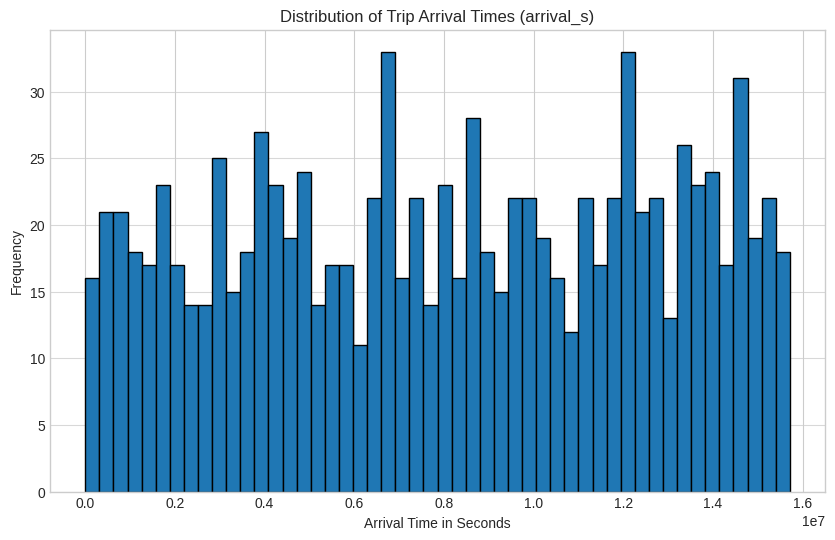

In [7]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.hist(trips_df['arrival_s'], bins=50, edgecolor='black')
plt.title('Distribution of Trip Arrival Times (arrival_s)')
plt.xlabel('Arrival Time in Seconds')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [8]:
import copy
import numpy as np
import pandas as pd # Ensure pandas is imported as it's used for DataFrame operations
from typing import Tuple # Added for Tuple type hint

def compress_data_to_fixed_duration(
    trips: pd.DataFrame,
    target_duration_hours: float = 2.0
) -> Tuple[pd.DataFrame, float]:
    """
    Compresses the trips DataFrame so the latest pickup_datetime occurs at target_duration_hours
    relative to the earliest pickup_datetime.
    The compression factor F = current_max_time_span / target_duration_seconds.
    """
    trips_new = trips.copy() # Work on a copy of the DataFrame to avoid modifying original

    target_s = target_duration_hours * 3600.0

    # 1. Determine original time span based on arrival_s
    t0_original_s = trips_new["arrival_s"].min()
    current_max_s = (trips_new["arrival_s"].max() - t0_original_s)

    if current_max_s <= 0:
        print("No time span to compress (or only one event), returning original data.")
        return trips_new, 1.0

    # Calculate Compression Factor F
    F = current_max_s / target_s

    # Apply compression to arrival_s
    # Shift times relative to t0_original_s, scale the difference, then add back t0_original_s
    trips_new["arrival_s"] = t0_original_s + (trips_new["arrival_s"] - t0_original_s) / F
    trips_new["arrival_s"] = trips_new["arrival_s"].astype(int) # Convert back to integer

    # Scale trip_duration by the same compression factor
    trips_new["trip_duration"] = (trips_new["trip_duration"] / F).astype(int)

    # Update pickup_datetime based on the compressed arrival_s
    # Find the original pickup_datetime corresponding to the earliest arrival_s
    t0_pickup_datetime = trips["pickup_datetime"].iloc[0]
    trips_new["pickup_datetime"] = t0_pickup_datetime + pd.to_timedelta(trips_new["arrival_s"], unit='s')

    print(f"Original timeline span: {current_max_s/3600:.2f}h")
    print(f"Target timeline span: {target_duration_hours:.2f}h")
    print(f"Compression Factor F: {F:.2f}")
    print(f"New max pickup_datetime: {trips_new['pickup_datetime'].max()}")
    # Also print the new max arrival_s for clarity
    print(f"New max arrival_s: {trips_new['arrival_s'].max()}")
    print(f"New max trip_duration: {trips_new['trip_duration'].max()}")

    return trips_new, F


In [9]:
trips_df = augment_trips_df(trips_df, CONFIG)
trips_df, F = compress_data_to_fixed_duration(trips=trips_df,target_duration_hours=CONFIG['horizon_hours'])

Dataset augmented from 999 to 2997 rows (factor: 3x).
Original timeline span: 4365.44h
Target timeline span: 3.00h
Compression Factor F: 1455.15
New max pickup_datetime: 2016-01-01 03:09:03
New max arrival_s: 10800
New max trip_duration: 58


In [10]:
trips_df.shape

(2997, 8)

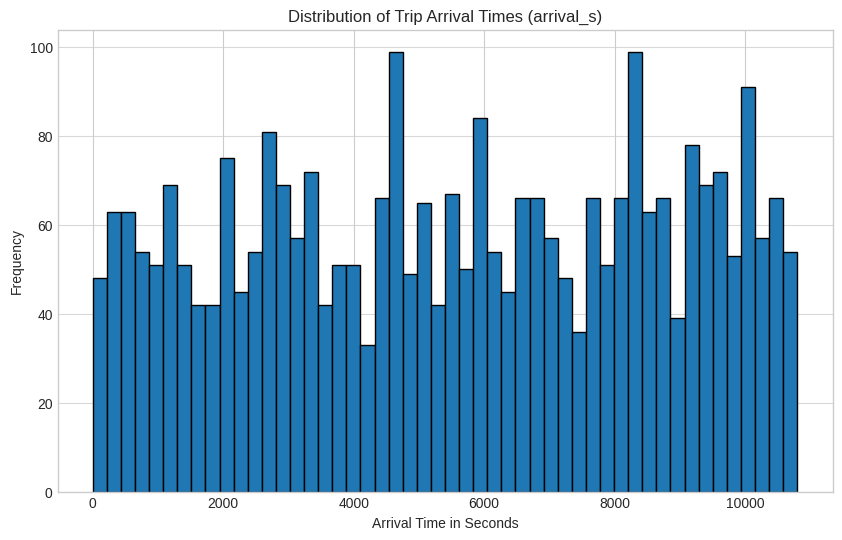

In [11]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.hist(trips_df['arrival_s'], bins=50, edgecolor='black')
plt.title('Distribution of Trip Arrival Times (arrival_s)')
plt.xlabel('Arrival Time in Seconds')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [12]:
#CONFIG['num_riders'] = int(len(trips_df) * CONFIG['rider_multipler_of_orders'])
#CONFIG['num_riders'] = 100
#print(f"Updated CONFIG['num_riders'] to: {CONFIG['num_riders']}")

In [13]:
import numpy as np

def haversine_km(a: tuple, b: tuple) -> float:
    lat1, lon1 = a
    lat2, lon2 = b
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    h = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dl/2)**2
    return float(2*R*np.arcsin(np.sqrt(h)))

# Combine all latitudes and longitudes from trips_df
all_lats = pd.concat([trips_df['pickup_latitude'], trips_df['dropoff_latitude']])
all_lons = pd.concat([trips_df['pickup_longitude'], trips_df['dropoff_longitude']])

# Find the geographical bounds of the data
min_lat = all_lats.min()
max_lat = all_lats.max()
min_lon = all_lons.min()
max_lon = all_lons.max()

# Calculate the maximum possible distance within these bounds
# Consider the two diagonal distances for a rectangle
dist1 = haversine_km((min_lat, min_lon), (max_lat, max_lon))
dist2 = haversine_km((min_lat, max_lon), (max_lat, min_lon))

max_data_span_km = max(dist1, dist2)

# Set service_radius_km to cover the entire span of the data, plus a buffer
CONFIG['service_radius_km'] = max_data_span_km * 1.1 # 10% buffer #np.inf

print(f"Updated CONFIG['service_radius_km'] to: {CONFIG['service_radius_km']:.2f} km")

Updated CONFIG['service_radius_km'] to: 74.18 km


## 3) Geometry + Ground-truth calibration

We compute `BASE_SPEED_KMPH` from observed trip durations.


In [14]:
def haversine_km(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    lat1, lon1 = a
    lat2, lon2 = b
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    h = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dl/2)**2
    return float(2*R*np.arcsin(np.sqrt(h)))


def estimate_base_speed_kmph(df: pd.DataFrame, speed_clip: Tuple[float,float]=(3.0, 80.0)) -> float:
    d_km = df.apply(lambda r: haversine_km((r.pickup_latitude, r.pickup_longitude), (r.dropoff_latitude, r.dropoff_longitude)), axis=1)
    dur_h = df["trip_duration"].astype(float) / 3600.0
    sp = d_km / dur_h
    sp = sp.replace([np.inf, -np.inf], np.nan).dropna()
    sp = sp[(sp >= speed_clip[0]) & (sp <= speed_clip[1])]
    if len(sp) == 0:
        return float(15.0)
    return float(np.median(sp))


def travel_time_minutes(dist_km: float, speed_kmph: float, congestion_factor: float) -> float:
    return 60.0 * (dist_km * congestion_factor) / max(speed_kmph, 1e-6)

# Calibrate baseline
CONFIG['BASE_SPEED_KMPH'] = estimate_base_speed_kmph(trips_df)
print('Estimated BASE_SPEED_KMPH:', round(CONFIG['BASE_SPEED_KMPH'], 2))


Estimated BASE_SPEED_KMPH: 15.0


## 4) Entities


In [15]:
@dataclass
class DarkStore:
    ds_id: int
    loc: Tuple[float, float]  # (lat, lon)


@dataclass
class Order:
    order_id: int
    arrival_time_s: int  # Re-added this attribute
    pickup_ds: int
    pickup_loc: Tuple[float, float]
    dropoff_loc: Tuple[float, float]
    gdt_deadline_s: int
    status: str = "unassigned"
    assigned_rider: Optional[int] = None
    assigned_time_s: Optional[int] = None
    delivered_time_s: Optional[int] = None


@dataclass
class Rider:
    rider_id: int
    speed_kmph: float
    service_radius_km: float
    arrival_time_s: int
    loc: Tuple[float, float]
    status: str = "idle"
    next_available_time_s: int = 0
    last_task_end_time_s: int = 0
    burden: int = 0
    earnings: float = 0.0
    busy_time_s: int = 0

    def is_available(self, t_s: int) -> bool:
        return (t_s >= self.arrival_time_s) and (self.status == "idle")

    def idle_time_s(self, t_s: int) -> int:
        if t_s < self.arrival_time_s or self.status == "busy":
            return 0
        return max(0, t_s - self.last_task_end_time_s)

## 5) Dark stores from pickups

k-means on pickup coordinates (fallback to frequent rounded cells).


In [16]:
def make_darkstores(trips: pd.DataFrame, cfg: Dict[str,Any], seed: int = 0) -> Dict[int,DarkStore]:
    k = int(cfg['num_darkstores'])
    X = trips[["pickup_latitude","pickup_longitude"]].to_numpy(dtype=float)

    km = KMeans(n_clusters=min(k, len(X)), random_state=seed, n_init=10)
    km.fit(X)
    centers = km.cluster_centers_
    return {i: DarkStore(i, (float(centers[i,0]), float(centers[i,1]))) for i in range(centers.shape[0])}

    p = 2
    keys = pd.Series(list(zip(trips["pickup_latitude"].round(p), trips["pickup_longitude"].round(p))))
    top = keys.value_counts().head(k).index.tolist()
    return {i: DarkStore(i, (float(lat), float(lon))) for i,(lat,lon) in enumerate(top)}


def assign_nearest_darkstore(pu: Tuple[float,float], darkstores: Dict[int,DarkStore]) -> int:
    return int(min(darkstores.keys(), key=lambda d: haversine_km(pu, darkstores[d].loc)))


darkstores = make_darkstores(trips_df, CONFIG, seed=0)
print("Darkstores:", len(darkstores))


Darkstores: 4


In [17]:
darkstores

{0: DarkStore(ds_id=0, loc=(40.73541081197078, -73.99322098124028)),
 1: DarkStore(ds_id=1, loc=(40.647573704300726, -73.78379896834981)),
 2: DarkStore(ds_id=2, loc=(40.76917640445935, -73.87097534707188)),
 3: DarkStore(ds_id=3, loc=(40.770332803712364, -73.96886630651225))}

 Trips  to Orders conversion

We keep the same q-commerce transformation:
- pickup_loc from pickup lat/lon
- dropoff_loc from dropoff lat/lon
- pickup_ds = nearest darkstore to pickup
- GDT deadline = arrival + 30 minutes



In [18]:
from datetime import datetime
def trips_to_orders(trips: pd.DataFrame, darkstores: Dict[int,DarkStore], cfg: Dict[str,Any]) -> List[Order]:
    gdt_s = int(cfg['gdt_minutes'] * 60)
    orders = []
    for i, row in enumerate(trips.itertuples(index=False)):
        pu = (float(row.pickup_latitude), float(row.pickup_longitude))
        do = (float(row.dropoff_latitude), float(row.dropoff_longitude))
        ds = assign_nearest_darkstore(pu, darkstores)
        arrival_s = int(row.arrival_s) #int((datetime.utcnow()-datetime.fromtimestamp(0)).total_seconds())
        orders.append(Order(order_id=i, arrival_time_s=arrival_s, pickup_ds=ds, pickup_loc=pu, dropoff_loc=do, gdt_deadline_s=arrival_s + gdt_s))
    return orders

orders = trips_to_orders(trips_df, darkstores, CONFIG)
print("Orders:", len(orders), "Example:", orders[0])

Orders: 2997 Example: Order(order_id=0, arrival_time_s=0, pickup_ds=0, pickup_loc=(40.748985290527344, -73.98435974121092), dropoff_loc=(40.71605682373047, -73.99628448486328), gdt_deadline_s=600, status='unassigned', assigned_rider=None, assigned_time_s=None, delivered_time_s=None)


Zones for fairness are coordinate-only:
- `grid` (default): rounding rider home lat/lon
- `kmeans`: clustering on rider home lat/lon



In [19]:
def init_riders(darkstores: Dict[int,DarkStore], cfg: Dict[str,Any], seed: int = 0) -> List[Rider]:
    rng = np.random.default_rng(seed)
    horizon_s = int(cfg['horizon_hours'] * 3600)
    ramp_s = int(min(horizon_s, cfg['rider_ramp_hours'] * 3600))
    ds_ids = list(darkstores.keys())

    riders = []
    for i in range(cfg['num_riders']):
        speed = float(rng.normal(cfg['rider_speed_kmph_mu'], cfg['rider_speed_kmph_sigma']))
        speed = max(cfg['rider_speed_kmph_min'], speed)
        arrival = int(rng.uniform(0, ramp_s))
        ds_loc = darkstores[int(rng.choice(ds_ids))].loc
        loc = (ds_loc[0] + float(rng.normal(0, 0.002)), ds_loc[1] + float(rng.normal(0, 0.002)))
        riders.append(Rider(i, speed, cfg['service_radius_km'], arrival, loc, 'idle', arrival, arrival))
    return riders


def assign_rider_zone_group(riders: List[Rider], cfg: Dict[str,Any], seed: int = 0) -> Dict[int,str]:
    mode = cfg.get('ZONE_GROUP_MODE','kmeans') # or use grid

    if mode == 'grid':
        p = int(cfg.get('ZONE_GRID_PRECISION', 2))
        return {r.rider_id: f"{round(r.loc[0],p)}_{round(r.loc[1],p)}" for r in riders}

    if mode == 'kmeans':
        k = int(cfg.get('ZONE_K', 30))
        X = np.array([[r.loc[0], r.loc[1]] for r in riders], dtype=float)
        km = KMeans(n_clusters=min(k, len(riders)), random_state=seed, n_init=10)
        labels = km.fit_predict(X)
        return {riders[i].rider_id: f"z{int(labels[i])}" for i in range(len(riders))}

    raise ValueError('Unknown ZONE_GROUP_MODE')


def effective_speed_kmph(r: Rider, cfg: Dict[str,Any]) -> float:
    """Rider speed anchored to BASE_SPEED_KMPH derived from observed trip_duration.
       Scales BASE_SPEED_KMPH by compression factor F if available."""
    base = float(cfg.get('BASE_SPEED_KMPH', cfg.get('rider_speed_kmph_mu', 15.0)))
    mu = float(cfg.get('rider_speed_kmph_mu', 15.0))

    # Access global compression factor F, if it exists and compression occurred
    # global F
    # if 'F' in globals() and F > 1.0:
    #     base_scaled = base * F
    # else:
    base_scaled = base

    return max(0.1, base_scaled * (float(r.speed_kmph) / max(mu, 1e-6)))

In [20]:
# calculate fairness score
def fairness_score(r: Rider, t_s: int, w1: float, w2: float) -> float:
    return w1 * (r.idle_time_s(t_s)/60.0) - w2 * r.burden


def batch_start_loc(batch: List[Order], darkstores: Dict[int,DarkStore]) -> Tuple[float,float]:
    return darkstores[batch[0].pickup_ds].loc


def route_duration_minutes(batch: List[Order], rider: Rider, darkstores: Dict[int,DarkStore], cfg: Dict[str,Any]) -> Tuple[float, Dict[int,float]]:
    cong = float(cfg['congestion_factor'])
    v_eff = effective_speed_kmph(rider, cfg)

    total = 0.0
    inc = {}
    prev = batch_start_loc(batch, darkstores)
    for o in batch:
        d = haversine_km(prev, o.dropoff_loc)
        total += travel_time_minutes(d, v_eff, cong)
        inc[o.order_id] = total
        prev = o.dropoff_loc
    return total, inc


def route_time_minutes(r: Rider, batch: List[Order], darkstores: Dict[int,DarkStore], cfg: Dict[str,Any]) -> Tuple[float, Dict[int,float]]:
    cong = float(cfg['congestion_factor'])
    v_eff = effective_speed_kmph(r, cfg)

    start = batch_start_loc(batch, darkstores)
    first = travel_time_minutes(haversine_km(r.loc, start), v_eff, cong)
    internal, inc = route_duration_minutes(batch, r, darkstores, cfg)
    return first + internal, {oid: first + v for oid, v in inc.items()}


def feasibility_pair(r: Rider, batch: List[Order], darkstores: Dict[int,DarkStore], t_s: int, cfg: Dict[str,Any]) -> bool:
    start = batch_start_loc(batch, darkstores)
    if haversine_km(r.loc, start) > r.service_radius_km:
        return False

    _, drop_mins = route_time_minutes(r, batch, darkstores, cfg)
    for o in batch:
        pass
        # drop_mins are already scaled (or should be consistent with scaled t_s and o.gdt_deadline_s)
        # The division by F was incorrect. t_s, drop_mins, and o.gdt_deadline_s should all be on the *same* compressed timeline.
        #if t_s + int(drop_mins[o.order_id] * 60) > o.gdt_deadline_s: return False # removed the GDT violation criteria for now
    return True

## 9) Baselines (NR / RR / WP)


In [21]:
def baseline_NR(riders: List[Rider], routes: List[List[Order]], darkstores: Dict[int,DarkStore], t_s: int, cfg: Dict[str,Any]) -> Dict[int, Optional[int]]:
    avail = [r for r in riders if r.is_available(t_s)]
    mapping = {r.rider_id: None for r in avail}

    cong = float(cfg['congestion_factor'])

    for j, batch in enumerate(routes):
        best = None
        best_first = float('inf')
        start = batch_start_loc(batch, darkstores)
        for r in avail:
            if mapping[r.rider_id] is not None:
                continue
            if not feasibility_pair(r, batch, darkstores, t_s, cfg):
                continue
            v_eff = effective_speed_kmph(r, cfg)
            first = travel_time_minutes(haversine_km(r.loc, start), v_eff, cong)
            if first < best_first:
                best_first = first
                best = r
        if best is not None:
            mapping[best.rider_id] = j

    assigned_real_routes = len([v for v in mapping.values() if v is not None])
    unassigned_riders = len([v for v in mapping.values() if v is None])
    print(f"  Assignment at t={t_s}s: {assigned_real_routes} real assignments, {unassigned_riders} unassigned riders")

    return mapping



In [22]:
def baseline_WP(riders: List[Rider], routes: List[List[Order]], darkstores: Dict[int,DarkStore], t_s: int, rng: np.random.Generator, cfg: Dict[str,Any]) -> Dict[int, Optional[int]]:
    avail = [r for r in riders if r.is_available(t_s)]
    if not avail:
        return {}

    mapping = {r.rider_id: None for r in avail}
    burdens = np.array([r.burden for r in avail], dtype=float)
    w = 1.0/(1.0 + burdens)
    w = w / w.sum()

    for j, batch in enumerate(routes):
        cand, ww = [], []
        for i, r in enumerate(avail):
            if mapping[r.rider_id] is not None:
                continue
            if feasibility_pair(r, batch, darkstores, t_s, cfg):
                cand.append(r)
                ww.append(w[i])
        if not cand:
            continue
        ww = np.array(ww); ww = ww/ww.sum()
        chosen = rng.choice(cand, p=ww)
        mapping[chosen.rider_id] = j

    assigned_real_routes = len([v for v in mapping.values() if v is not None])
    unassigned_riders = len([v for v in mapping.values() if v is None])
    print(f"  Assignment at t={t_s}s: {assigned_real_routes} real assignments, {unassigned_riders} unassigned riders")

    return mapping


In [23]:
def baseline_RR(riders: List[Rider], routes: List[List[Order]], darkstores: Dict[int,DarkStore], t_s: int, rr_state: Dict[str,int], cfg: Dict[str,Any]) -> Dict[int, Optional[int]]:
    avail = sorted([r for r in riders if r.is_available(t_s)], key=lambda r: r.rider_id)
    if not avail:
        return {}

    mapping = {r.rider_id: None for r in avail}
    idx = rr_state.get('idx', 0) % len(avail)

    for j, batch in enumerate(routes):
        tried = 0
        while tried < len(avail):
            r = avail[idx]
            idx = (idx + 1) % len(avail)
            tried += 1
            if mapping[r.rider_id] is not None:
                continue
            if feasibility_pair(r, batch, darkstores, t_s, cfg):
                mapping[r.rider_id] = j
                break

    rr_state['idx'] = idx

    assigned_real_routes = len([v for v in mapping.values() if v is not None])
    unassigned_riders = len([v for v in mapping.values() if v is None])
    print(f"  Assignment at t={t_s}s: {assigned_real_routes} real assignments, {unassigned_riders} unassigned riders")

    return mapping

Stage 1: create routes using VRP

In [24]:
def solve_vrp_routes_for_darkstore(orders_ds: List[Order], ds: DarkStore, cfg: Dict[str,Any]) -> List[List[int]]:
    max_batch_size = int(cfg['max_batch_size'])
    time_limit_s = int(cfg['vrp_time_limit_seconds'])

    if not orders_ds:
        return []

    if True :
        remaining = set(range(len(orders_ds)))
        routes = []
        while remaining:
            seed = next(iter(remaining))
            remaining.remove(seed)
            route = [seed]
            while len(route) < max_batch_size and remaining:
                last = route[-1]
                nxt = min(remaining, key=lambda j: haversine_km(orders_ds[last].dropoff_loc, orders_ds[j].dropoff_loc))
                route.append(nxt)
                remaining.remove(nxt)
            routes.append(route)
        return routes

    base = float(cfg.get('BASE_SPEED_KMPH', cfg.get('rider_speed_kmph_mu', 15.0)))
    cong = float(cfg['congestion_factor'])

    locs = [ds.loc] + [o.dropoff_loc for o in orders_ds]
    n = len(locs)
    cost = np.zeros((n,n), dtype=int)
    for i in range(n):
        for j in range(n):
            d = haversine_km(locs[i], locs[j])
            cost[i,j] = int(travel_time_minutes(d, base, cong) * 60)

    num_vehicles = len(orders_ds)
    depot = 0
    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, depot)
    routing = pywrapcp.RoutingModel(manager)

    def cost_cb(from_i, to_i):
        a = manager.IndexToNode(from_i)
        b = manager.IndexToNode(to_i)
        return int(cost[a,b])

    transit = routing.RegisterTransitCallback(cost_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit)

    def demand_cb(from_i):
        node = manager.IndexToNode(from_i)
        return 0 if node == 0 else 1

    demand = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(demand, 0, [max_batch_size]*num_vehicles, True, 'Capacity')

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit_s)

    sol = routing.SolveWithParameters(params)
    if sol is None:
        return [[i] for i in range(len(orders_ds))]

    routes = []
    for v in range(num_vehicles):
        idx = routing.Start(v)
        route = []
        while not routing.IsEnd(idx):
            node = manager.IndexToNode(idx)
            if node != 0:
                route.append(node - 1)
            idx = sol.Value(routing.NextVar(idx))
        if route:
            routes.append(route)
    return routes


def stage1_generate_routes(pending: List[Order], darkstores: Dict[int,DarkStore], cfg: Dict[str,Any]) -> List[List[Order]]:
    by_ds: Dict[int, List[Order]] = {}
    for o in pending:
        by_ds.setdefault(o.pickup_ds, []).append(o)

    batches: List[List[Order]] = []
    for ds_id, orders_ds in by_ds.items():
        idx_routes = solve_vrp_routes_for_darkstore(orders_ds, darkstores[ds_id], cfg)
        for ridx in idx_routes:
            batches.append([orders_ds[i] for i in ridx])
    return batches


stage 2: Hungarian assignment


In [25]:
def mydecorator(fn):
    def inner_function(*args, **kwargs):
        print(fn.__name__, end='\n')
        return fn(*args, **kwargs)
    return inner_function


In [26]:
def stage2_hungarian_assignment(riders, routes, darkstores, t_s, lam, cfg):
    w1 = cfg['w1_idle']; w2 = cfg['w2_burden']
    avail = [r for r in riders if r.is_available(t_s)]
    if not avail or not routes:
        return {}

    n_r = len(avail)
    n_b = len(routes)

    BIG_M = 1e7
    # A large, but finite penalty for GDT violations to make them undesirable but not impossible
    GDT_PENALTY = 10000.0

    # Initialize cost matrix without dummy columns
    C = np.full((n_r, n_b), BIG_M, dtype=float)

    feasible_pairs = 0
    for i, r in enumerate(avail):
        fr = fairness_score(r, t_s, w1, w2)
        for j, batch in enumerate(routes):
            start = batch_start_loc(batch, darkstores)

            # Retain the service radius check as a hard constraint
            if haversine_km(r.loc, start) > r.service_radius_km:
                continue # This rider cannot reach the darkstore for this batch

            # Calculate route time, which will be used in cost and for GDT check
            # route_time_minutes returns (total_minutes, {order_id: minutes_to_dropoff})
            total_route_min, drop_min_per_order = route_time_minutes(r, batch, darkstores, cfg)

            current_gdt_penalty = 0.0
            for o in batch:
                # Convert dropoff time for this order to seconds from t_s
                delivered_time_s = t_s + int(drop_min_per_order[o.order_id] * 60)
                if delivered_time_s > o.gdt_deadline_s:
                    current_gdt_penalty += GDT_PENALTY # Add penalty for each violated order

            # Calculate the cost for this rider-batch pair
            # If GDT was violated, the penalty is added
            cost_value = (1 - lam) * total_route_min - lam * fr + current_gdt_penalty
            C[i, j] = cost_value
            feasible_pairs += 1 # Count as 'feasible' if service radius check passes

    ri, cj = linear_sum_assignment(C)

    # Initialize output dictionary with all available riders unassigned
    out = {r.rider_id: None for r in avail}
    assigned_real_routes = 0

    for i, j in zip(ri, cj):
        # Only consider assignments that are actually feasible (cost is not BIG_M)
        if C[i, j] < BIG_M/10: # Using BIG_M/10 to account for potential floating point inaccuracies
            out[avail[i].rider_id] = j
            assigned_real_routes += 1

    assigned_dummy_routes = len(avail) - assigned_real_routes
    print(f"  Assignment at t={t_s}s: {assigned_real_routes} real assignments, {assigned_dummy_routes} unassigned riders")
    return out

In [27]:
def refresh_riders(riders: List[Rider], t_s: int):
    for r in riders:
        if r.status == 'busy' and t_s >= r.next_available_time_s:
            r.status = 'idle'


def compute_exact_batch_metrics(route_logs: List[Dict[str,Any]]):
    if not route_logs:
        return {
            'routes_assigned': 0,
            'orders_delivered': 0,
            'avg_batch_size': np.nan,
            'pct_batched': np.nan,
            'batch_size_p50': np.nan,
            'batch_size_p90': np.nan,
            'batch_size_max': np.nan,
        }
    bs = np.array([l['batch_size'] for l in route_logs], dtype=float)
    return {
        'routes_assigned': int(len(route_logs)),
        'orders_delivered': int(bs.sum()),
        'avg_batch_size': float(bs.mean()),
        'pct_batched': float(np.mean(bs > 1)),
        'batch_size_p50': float(np.quantile(bs, 0.5)),
        'batch_size_p90': float(np.quantile(bs, 0.9)),
        'batch_size_max': float(bs.max()),
    }


In [28]:
def group_fairness_metrics(earnings: np.ndarray, groups: np.ndarray):
    df = pd.DataFrame({'group': groups, 'earn': earnings})
    means = df.groupby('group')['earn'].mean().sort_values(ascending=False)
    overall = float(df['earn'].mean()) if len(df) else np.nan
    dp_gap = float((means - overall).abs().max()) if len(means) else np.nan
    cv = float(means.std(ddof=1)/means.mean()) if len(means) > 1 and means.mean() != 0 else 0.0
    summary = {
        'groups': int(len(means)),
        'overall_mean': overall,
        'dp_gap': dp_gap,
        'cv_group_means': cv,
    }
    return means, summary


In [29]:
def rider_retention_metrics(
    earnings: np.ndarray,
    delivered: int,
    received: int,
    threshold_quantile: float = 0.25,
    sensitivity: float = 1.5,
) -> Dict[str, float]:
    """
    Estimate long-term reliability impact of the current earnings distribution.

    Parameters
    ----------
    earnings            : per-rider earnings array from the simulation run
    delivered / received: order counts for this run
    threshold_quantile  : riders below this quantile of earnings are 'at-risk'
                          of churning (default: bottom 25 %)
    sensitivity         : each 1 pp increase in at-risk riders reduces OFR by
                          `sensitivity` pp (calibrate from historical data;
                          1.5 is a conservative default)

    Returns
    -------
    dict with:
        churn_threshold        — earnings level below which a rider is at-risk
        pct_riders_at_risk     — fraction of riders at risk (0-1)
        projected_ofr_loss     — expected OFR reduction if at-risk riders leave
        projected_ofr          — projected future OFR after churn
    """
    if len(earnings) == 0 or received == 0:
        return {
            'churn_threshold': np.nan,
            'pct_riders_at_risk': np.nan,
            'projected_ofr_loss': np.nan,
            'projected_ofr': np.nan,
        }

    threshold = float(np.quantile(earnings, threshold_quantile))
    pct_at_risk = float(np.mean(earnings < threshold))

    current_ofr = delivered / received
    # Linear sensitivity model:  ΔOFR = -sensitivity × pct_at_risk
    projected_ofr_loss = sensitivity * pct_at_risk / 100.0   # convert pp → fraction
    projected_ofr = max(0.0, current_ofr - projected_ofr_loss)

    return {
        'churn_threshold':    threshold,
        'pct_riders_at_risk': pct_at_risk,
        'projected_ofr_loss': projected_ofr_loss,
        'projected_ofr':      projected_ofr,
    }

In [30]:
def lambda_for_epoch(t_s: int, schedule: Dict[Tuple[int,int], float],
                     default_lam: float = 0.5) -> float:
    """
    Given epoch time t_s (seconds from simulation start) and a schedule
    keyed by (hour_start, hour_end) → λ, return the appropriate λ.

    The schedule uses wall-clock hours (0-23).  Because the simulation
    compresses real timestamps, we map t_s → hour via modulo arithmetic.
    """
    hour = int((t_s % 86400) / 3600)          # hour-of-day (0-23)
    for (h_start, h_end), lam in schedule.items():
        if h_start <= hour < h_end:
            return lam
    return default_lam                         # fallback if no bucket matches

In [31]:
import numpy as np
import bisect

def gini_coefficient(earnings: np.ndarray) -> float:
    """Calculates the Gini coefficient for a given array of earnings."""
    if len(earnings) == 0:
        return np.nan

    # Ensure earnings are non-negative
    earnings = np.maximum(0, earnings)
    if np.sum(earnings) == 0:
        return 0.0 # If all earnings are zero, Gini is 0

    sorted_earnings = np.sort(earnings)
    n = len(sorted_earnings)
    # Lorenz curve values
    lorenz = np.cumsum(sorted_earnings) / np.sum(sorted_earnings)
    # Gini coefficient formula (simplified from trapezoidal rule for discrete data)
    # A = 0.5 * sum((lorenz[i] + lorenz[i-1]) * (x[i] - x[i-1]))
    # B = 0.5
    # G = (A - B) / B = 2*A - 1

    # Formula for Gini coefficient for discrete data, alternative calculation:
    # G = (1/n) * (n + 1 - 2 * sum((n - i) * sorted_earnings[i]) / sum(sorted_earnings))
    # A more common formula for discrete data, when data is already sorted:
    index = np.arange(1, n + 1)
    gini = (np.sum((2 * index - n - 1) * sorted_earnings)) / (n * np.sum(sorted_earnings))
    return float(gini)


In [32]:

# def run_simulation(orders: List[Order], darkstores: Dict[int,DarkStore], riders: List[Rider],cfg: Dict[str,Any],
#                    lam: float, policy: str, seed: int = 0,
#                    precomputed_routes_by_epoch: Dict[int, List[List[Order]]] = None):
#     # Deep copy orders for this simulation run to manage their mutable state (status, assigned_rider etc.)
#     # The orders list passed to this function should already be the correct, flattened list
#     # derived from precomputed_routes_by_epoch if precomputation is used.
#     #orders = copy.deepcopy(orders)

#     rider_map = {r.rider_id: r for r in riders}
#     rider_groups = assign_rider_zone_group(riders, cfg, seed=seed,)

#     horizon_s = int(cfg['horizon_hours'] * 3600)
#     epoch_s = int(cfg['epoch_seconds'])

#     pending: List[Order] = [] # Stores orders that have arrived and are awaiting assignment
#     ptr = 0
#     rr_state = {'idx': 0}
#     rng = np.random.default_rng(seed)

#     route_logs: List[Dict[str,Any]] = []

#     for t_s in range(0, horizon_s + 1, epoch_s):
#         refresh_riders(riders, t_s)

#         # Add newly arrived orders to the `pending` list
#         while ptr < len(orders) and orders[ptr].arrival_time_s <= t_s:
#             # Only add unassigned orders to the pending list for consideration
#             # orders[ptr].status will be 'unassigned' when it first arrives
#             pending.append(orders[ptr])
#             ptr += 1

#         # Filter pending orders to only include those that are truly unassigned and have arrived by t_s
#         current_pending_unassigned_orders = [o for o in pending if o.status == 'unassigned' and o.arrival_time_s <= t_s]
#         if not current_pending_unassigned_orders:
#             continue

#         # check if there are any available riders at time t_s
#         available_riders = [r for r in riders if r.is_available(t_s)]
#         if not available_riders:
#             # optional debug
#             # print(f"T:{t_s} pending={len(pending)} but no available riders. Skipping dispatch.")
#             continue

#         # --- Route generation moved out ---
#         routes: List[List[Order]] = []
#         if precomputed_routes_by_epoch is not None:
#             # Retrieve pre-computed routes for this epoch
#             all_potential_routes_for_epoch = precomputed_routes_by_epoch.get(t_s, [])

#             # Filter these pre-computed routes to only include those composed entirely
#             # of orders that are currently unassigned and pending.
#             pending_order_ids = {o.order_id for o in current_pending_unassigned_orders}

#             for batch in all_potential_routes_for_epoch:
#                 # Check if all orders in the batch are in the current_pending_unassigned_orders set
#                 if all(o.order_id in pending_order_ids for o in batch):
#                     routes.append(batch)
#         else:
#             # Fallback to dynamic generation if precomputed routes are not provided
#             # This path is primarily for ensuring backwards compatibility or if the precomputation is skipped.
#             print(f"Warning: precomputed_routes_by_epoch not provided for T:{t_s}, generating routes dynamically.")
#             routes = stage1_generate_routes(current_pending_unassigned_orders, darkstores, cfg)

#         if not routes:
#             continue

#         print(f'T:{t_s} len(available_riders): {len(available_riders)} len(routes) :{len(routes)} , total orders :{len(orders)} pending orders : {len(current_pending_unassigned_orders)} , policy :{policy}, lam: {lam}, rep:{seed}') # :{pending})
#         #print(routes)

#         # if policy == 'two_stage':
#         #     assignment = stage2_hungarian_assignment(riders, routes, darkstores, t_s, lam, cfg)
#         # ── AFTER (adaptive-λ aware) ───────────────

#         if policy == 'two_stage':
#             if lam == -1.0:                            # -1 is our sentinel for "adaptive"
#                 effective_lam = lambda_for_epoch(
#                     t_s,
#                     cfg.get('urgency_lambda_schedule', {}),
#                     default_lam=0.5
#                 )
#             else:
#                 effective_lam = lam
#             assignment = stage2_hungarian_assignment(
#                 riders, routes, darkstores, t_s, effective_lam, cfg
#             )
#         elif policy == 'NR':
#             assignment = baseline_NR(riders, routes, darkstores, t_s, cfg)
#         elif policy == 'RR':
#             assignment = baseline_RR(riders, routes, darkstores, t_s, rr_state, cfg)
#         elif policy == 'WP':
#             assignment = baseline_WP(riders, routes, darkstores, t_s, rng, cfg)
#         else:
#             raise ValueError('Unknown policy')

#         #print(f'assignment :{assignment} ')
#         #breakpoint()

#         apply_assignment_with_logging(rider_map, routes, assignment, t_s, darkstores, cfg, route_logs)

#         # After assignments are applied, update the 'pending' list to remove delivered orders.
#         # The next iteration will add new orders and then filter for unassigned.
#         pending = [o for o in pending if o.status == 'unassigned']

#     delivered = [o for o in orders if o.status == 'delivered']
#     received = len([o for o in orders if o.arrival_time_s <= horizon_s])
#     unassigned_final = [o for o in orders if o.status == 'unassigned']

#     print("\n--- Simulation Summary ---")
#     print(f"Total orders considered: {len(orders)}")
#     print(f"Orders delivered: {len(delivered)}")
#     print(f"Orders unassigned: {len(unassigned_final)}")
#     if unassigned_final:
#         print("Unassigned order IDs:", len([o.order_id for o in unassigned_final]))

#     if delivered:
#         adt = float(np.mean([(o.delivered_time_s - o.arrival_time_s) / 60.0 for o in delivered]))
#         gdt_viol = float(np.mean([1.0 if o.delivered_time_s > o.gdt_deadline_s else 0.0 for o in delivered]))
#     else:
#         adt = np.nan
#         gdt_viol = np.nan

#     ofr = float(len(delivered) / received) if received else np.nan

#     earnings = np.array([r.earnings for r in riders], dtype=float)
#     gini_earnings = gini_coefficient(earnings)
#     groups = np.array([rider_groups[r.rider_id] for r in riders])

#     # Calculate rider utilization metrics
#     rider_utilizations = np.array([r.busy_time_s / horizon_s for r in riders])
#     avg_utilization = float(np.mean(rider_utilizations))
#     min_utilization = float(np.min(rider_utilizations))
#     max_utilization = float(np.max(rider_utilizations))
#     std_utilization = float(np.std(rider_utilizations))

#     # Calculate total idle time across all riders
#     total_idle_time_s = sum([r.idle_time_s(horizon_s) for r in riders]) # Use horizon_s as current time to calculate final idle time

#     batch_metrics = compute_exact_batch_metrics(route_logs)
#     group_means, group_summary = group_fairness_metrics(earnings, groups)
#     # ── Reviewer addition: retention & long-run reliability metrics ─────────────
#     retention = rider_retention_metrics(
#         earnings=earnings,
#         delivered=len(delivered),
#         received=received,
#     )

#     # PoF will be calculated in run_experiments

#     return {
#         'policy': policy,
#         'lambda': lam,
#         'seed': seed,
#         'ADT_min': adt,
#         'GDT_violation_rate': gdt_viol,
#         'delivered': len(delivered),
#         'received': received,
#         'OFR': ofr,
#         'batch_avg_batch_size': batch_metrics['avg_batch_size'],
#         'batch_pct_batched': batch_metrics['pct_batched'],
#         'batch_routes_assigned': batch_metrics['routes_assigned'],
#         'group_dp_gap': group_summary['dp_gap'],
#         'group_cv_means': group_summary['cv_group_means'],
#         'groups_count': group_summary['groups'],
#         'avg_rider_utilization': avg_utilization,
#         'min_rider_utilization': min_utilization,
#         'max_rider_utilization': max_utilization,
#         'std_rider_utilization': std_utilization,
#         'total_idle_time_s': float(total_idle_time_s),
#         'route_logs': route_logs if cfg.get('STORE_ROUTE_LOGS', True) else None,
#         'group_means': group_means,
#         'earnings': earnings,
#         'gini_coefficient_earnings': gini_earnings,
#         # ── NEW ───────────────────────
#         'churn_threshold':     retention['churn_threshold'],
#         'pct_riders_at_risk':  retention['pct_riders_at_risk'],
#         'projected_ofr_loss':  retention['projected_ofr_loss'],
#         'projected_ofr':       retention['projected_ofr'],
#     }



In [33]:
import numpy as np
import bisect
import copy # Import copy module for deepcopy functionality

def gini_coefficient(earnings: np.ndarray) -> float:
    """Calculates the Gini coefficient for a given array of earnings."""
    if len(earnings) == 0:
        return np.nan

    # Ensure earnings are non-negative
    earnings = np.maximum(0, earnings)
    if np.sum(earnings) == 0:
        return 0.0 # If all earnings are zero, Gini is 0

    sorted_earnings = np.sort(earnings)
    n = len(sorted_earnings)
    # Lorenz curve values
    # lorenz = np.cumsum(sorted_earnings) / np.sum(sorted_earnings)
    # Gini coefficient formula (simplified from trapezoidal rule for discrete data)
    # A = 0.5 * sum((lorenz[i] + lorenz[i-1]) * (x[i] - x[i-1]))
    # B = 0.5
    # G = (A - B) / B = 2*A - 1

    # Formula for Gini coefficient for discrete data, alternative calculation:
    # G = (1/n) * (n + 1 - 2 * sum((n - i) * sorted_earnings[i]) / sum(sorted_earnings))
    # A more common formula for discrete data, when data is already sorted:
    index = np.arange(1, n + 1)
    gini = (np.sum((2 * index - n - 1) * sorted_earnings)) / (n * np.sum(sorted_earnings))
    return float(gini)

def run_simulation_with_slow_gini(orders: List[Order], darkstores: Dict[int,DarkStore], riders: List[Rider],cfg: Dict[str,Any],
                   lam: float, policy: str, seed: int = 0,
                   precomputed_routes_by_epoch: Dict[int, List[List[Order]]] = None):
    # Deep copy orders for this simulation run to manage their mutable state (status, assigned_rider etc.)
    # The orders list passed to this function should already be the correct, flattened list
    # derived from precomputed_routes_by_epoch if precomputation is used.
    #orders = copy.deepcopy(orders)

    rider_map = {r.rider_id: r for r in riders}
    rider_groups = assign_rider_zone_group(riders, cfg, seed=seed,)

    horizon_s = int(cfg['horizon_hours'] * 3600)
    epoch_s = int(cfg['epoch_seconds'])

    pending: List[Order] = [] # Stores orders that have arrived and are awaiting assignment
    ptr = 0
    rr_state = {'idx': 0}
    rng = np.random.default_rng(seed)

    route_logs: List[Dict[str,Any]] = []

    for t_s in range(0, horizon_s + 1, epoch_s):
        refresh_riders(riders, t_s)

        # Add newly arrived orders to the `pending` list
        while ptr < len(orders) and orders[ptr].arrival_time_s <= t_s:
            # Only add unassigned orders to the pending list for consideration
            # orders[ptr].status will be 'unassigned' when it first arrives
            pending.append(orders[ptr])
            ptr += 1

        # Filter pending orders to only include those that are truly unassigned and have arrived by t_s
        current_pending_unassigned_orders = [o for o in pending if o.status == 'unassigned' and o.arrival_time_s <= t_s]
        if not current_pending_unassigned_orders:
            continue

        # check if there are any available riders at time t_s
        available_riders = [r for r in riders if r.is_available(t_s)]
        if not available_riders:
            # optional debug
            # print(f"T:{t_s} pending={len(pending)} but no available riders. Skipping dispatch.")
            continue

        # --- Route generation moved out ---
        routes: List[List[Order]] = []
        if precomputed_routes_by_epoch is not None:
            # Retrieve pre-computed routes for this epoch
            all_potential_routes_for_epoch = precomputed_routes_by_epoch.get(t_s, [])

            # Filter these pre-computed routes to only include those composed entirely
            # of orders that are currently unassigned and pending.
            pending_order_ids = {o.order_id for o in current_pending_unassigned_orders}

            for batch in all_potential_routes_for_epoch:
                # Check if all orders in the batch are in the current_pending_unassigned_orders set
                if all(o.order_id in pending_order_ids for o in batch):
                    routes.append(batch)
        else:
            # Fallback to dynamic generation if precomputed routes are not provided
            # This path is primarily for ensuring backwards compatibility or if the precomputation is skipped.
            print(f"Warning: precomputed_routes_by_epoch not provided for T:{t_s}, generating routes dynamically.")
            routes = stage1_generate_routes(current_pending_unassigned_orders, darkstores, cfg)

        if not routes:
            continue

        print(f'T:{t_s} len(available_riders): {len(available_riders)} len(routes) :{len(routes)} , total orders :{len(orders)} pending orders : {len(current_pending_unassigned_orders)} , policy :{policy}, lam: {lam}, rep:{seed}') # :{pending})
        #print(routes)

        # if policy == 'two_stage':
        #     assignment = stage2_hungarian_assignment(riders, routes, darkstores, t_s, lam, cfg)
        # ── AFTER (adaptive-λ aware) ────────────────

        if policy == 'two_stage':
            if lam == -1.0:                            # -1 is our sentinel for "adaptive"
                effective_lam = lambda_for_epoch(
                    t_s,
                    cfg.get('urgency_lambda_schedule', {}),
                    default_lam=0.5
                )
            else:
                effective_lam = lam
            assignment = stage2_hungarian_assignment(
                riders, routes, darkstores, t_s, effective_lam, cfg
            )
        elif policy == 'NR':
            assignment = baseline_NR(riders, routes, darkstores, t_s, cfg)
        elif policy == 'RR':
            assignment = baseline_RR(riders, routes, darkstores, t_s, rr_state, cfg)
        elif policy == 'WP':
            assignment = baseline_WP(riders, routes, darkstores, t_s, rng, cfg)
        else:
            raise ValueError('Unknown policy')

        #print(f'assignment :{assignment} ')
        #breakpoint()

        apply_assignment_with_logging(rider_map, routes, assignment, t_s, darkstores, cfg, route_logs)

        # After assignments are applied, update the 'pending' list to remove delivered orders.
        # The next iteration will add new orders and then filter for unassigned.
        pending = [o for o in pending if o.status == 'unassigned']

    delivered = [o for o in orders if o.status == 'delivered']
    received = len([o for o in orders if o.arrival_time_s <= horizon_s])
    unassigned_final = [o for o in orders if o.status == 'unassigned']

    print("\n--- Simulation Summary ---")
    print(f"Total orders considered: {len(orders)}")
    print(f"Orders delivered: {len(delivered)}")
    print(f"Orders unassigned: {len(unassigned_final)}")
    if unassigned_final:
        print("Unassigned order IDs:", len([o.order_id for o in unassigned_final]))

    if delivered:
        adt = float(np.mean([(o.delivered_time_s - o.arrival_time_s) / 60.0 for o in delivered]))
        gdt_viol = float(np.mean([1.0 if o.delivered_time_s > o.gdt_deadline_s else 0.0 for o in delivered]))
    else:
        adt = np.nan
        gdt_viol = np.nan

    ofr = float(len(delivered) / received) if received else np.nan
    #pof = 1.0 - ofr # Price of Fairness (or Inefficiency)

    earnings = np.array([r.earnings for r in riders], dtype=float)
    gini_earnings = gini_coefficient(earnings)
    groups = np.array([rider_groups[r.rider_id] for r in riders])

    # Calculate rider utilization metrics
    rider_utilizations = np.array([r.busy_time_s / horizon_s for r in riders])
    avg_utilization = float(np.mean(rider_utilizations))
    min_utilization = float(np.min(rider_utilizations))
    max_utilization = float(np.max(rider_utilizations))
    std_utilization = float(np.std(rider_utilizations))

    # Calculate total idle time across all riders
    total_idle_time_s = sum([r.idle_time_s(horizon_s) for r in riders]) # Use horizon_s as current time to calculate final idle time

    # --- Categorize riders by speed and calculate Gini for each group ---
    rider_speeds = np.array([r.speed_kmph for r in riders])
    median_speed = np.median(rider_speeds)

    # Create masks for slow and fast riders
    slow_rider_mask = (rider_speeds <= median_speed)
    fast_rider_mask = (rider_speeds > median_speed)

    # Extract earnings for slow and fast riders
    slow_earnings = earnings[slow_rider_mask]
    fast_earnings = earnings[fast_rider_mask]

    # Calculate Gini for each group
    gini_slow_riders = gini_coefficient(slow_earnings)
    gini_fast_riders = gini_coefficient(fast_earnings)
    #print(gini_fast_riders,gini_slow_riders)
    # -------------------------------------------------------------------

    batch_metrics = compute_exact_batch_metrics(route_logs)
    group_means, group_summary = group_fairness_metrics(earnings, groups)
    # ── Reviewer addition: retention & long-run reliability metrics ─────────────
    retention = rider_retention_metrics(
        earnings=earnings,
        delivered=len(delivered),
        received=received,
    )

    # Calculate total travel time for all assigned routes
    total_travel_time_min = sum([log['total_min'] for log in route_logs]) if route_logs else 0.0

    return {
        'policy': policy,
        'lambda': lam,
        'seed': seed,
        'ADT_min': adt,
        'GDT_violation_rate': gdt_viol,
        'delivered': len(delivered),
        'received': received,
        'OFR': ofr,
        #'pof': pof, # NEW: Price of Fairness - moved to run_experiments
        'batch_avg_batch_size': batch_metrics['avg_batch_size'],
        'batch_pct_batched': batch_metrics['pct_batched'],
        'batch_routes_assigned': batch_metrics['routes_assigned'],
        'group_dp_gap': group_summary['dp_gap'],
        'group_cv_means': group_summary['cv_group_means'],
        'groups_count': group_summary['groups'],
        'avg_rider_utilization': avg_utilization,
        'min_rider_utilization': min_utilization,
        'max_rider_utilization': max_utilization,
        'std_rider_utilization': std_utilization,
        'total_idle_time_s': float(total_idle_time_s),
        'route_logs': route_logs if cfg.get('STORE_ROUTE_LOGS', True) else None,
        'group_means': group_means,
        'earnings': earnings,
        'gini_coefficient_earnings': gini_earnings,
        'gini_slow_riders': gini_slow_riders, # NEW
        'gini_fast_riders': gini_fast_riders, # NEW
        # ── NEW ───────────────────────
        'churn_threshold':     retention['churn_threshold'],
        'pct_riders_at_risk':  retention['pct_riders_at_risk'],
        'projected_ofr_loss':  retention['projected_ofr_loss'],
        'projected_ofr':       retention['projected_ofr'],
        'total_travel_time_min': total_travel_time_min, # NEW METRIC
    }

def apply_assignment_with_logging(rider_map: Dict[int,Rider], routes: List[List[Order]], assignment: Dict[int,Optional[int]],
                                 t_s: int, darkstores: Dict[int,DarkStore], cfg: Dict[str,Any], route_logs: List[Dict[str,Any]]):
    cong = float(cfg['congestion_factor'])

    for rid, j in assignment.items():
        if j is None:
            continue

        r = rider_map[rid]
        batch = routes[j]

        start_loc = batch_start_loc(batch, darkstores)
        v_eff = effective_speed_kmph(r, cfg)
        first_mile_km = haversine_km(r.loc, start_loc)
        first_mile_min = travel_time_minutes(first_mile_km, v_eff, cong)

        internal_min, internal_inc = route_duration_minutes(batch, r, darkstores, cfg)
        total_min = first_mile_min + internal_min
        finish_s = t_s + int(total_min * 60)

        per_order = []
        gdt_viol_count = 0
        for o in batch:
            delivered_time_s = t_s + int((first_mile_min + internal_inc[o.order_id]) * 60)
            viol = delivered_time_s > o.gdt_deadline_s
            gdt_viol_count += int(viol)
            per_order.append({
                'order_id': o.order_id,
                'delivered_time_s': delivered_time_s,
                'gdt_deadline_s': o.gdt_deadline_s,
                'gdt_viol': bool(viol),
            })

        r.status = 'busy'
        r.next_available_time_s = finish_s
        r.busy_time_s += max(0, finish_s - t_s)
        r.burden += len(batch)
        r.earnings += float(len(batch))
        r.loc = batch[-1].dropoff_loc
        r.last_task_end_time_s = finish_s

        if os.environ.get('VERBOSE', False):
            print(f"Epoch {t_s/60:.0f} min: Rider {rid} completed route, delivering orders {[o['order_id'] for o in per_order]} and is now available at {finish_s/60:.0f} min.")

        for o in batch:
            o.status = 'delivered'
            o.assigned_rider = rid
            o.assigned_time_s = t_s
        for rec in per_order:
            oid = rec['order_id']
            for o in batch:
                if o.order_id == oid:
                    o.delivered_time_s = rec['delivered_time_s']
                    break

        route_logs.append({
            'epoch_s': t_s,
            'rider_id': rid,
            'pickup_ds': batch[0].pickup_ds,
            'batch_size': len(batch),
            'trip_ids': [o.order_id for o in batch],
            'first_mile_min': first_mile_min,
            'internal_min': internal_min,
            'total_min': total_min,
            'finish_s': finish_s,
            'gdt_violations_in_batch': gdt_viol_count,
            'per_order': per_order,
        })

In [34]:
def run_experiments(cfg: Dict[str,Any], orders: List[Order], darkstores: Dict[int,DarkStore], riders: List[Rider],
                    policies: List[str] = None):
    if policies is None:
        policies = ['two_stage', 'NR', 'RR', 'WP']

    horizon_s = int(cfg['horizon_hours'] * 3600)
    epoch_s = int(cfg['epoch_seconds'])

    # --- Pre-compute routes for all epochs outside run_simulation ---
    # Sort orders by arrival time to process them sequentially
    all_initial_orders_sorted = sorted(orders, key=lambda o: o.arrival_time_s)
    precomputed_routes_by_epoch: Dict[int, List[List[Order]]] = {}

    print("Pre-computing routes for all epochs...")
    for t_s in range(0, horizon_s + 1, epoch_s):
        # Find the start index for orders arriving in the current epoch window [t_s - epoch_s, t_s]
        # bisect_left finds insertion point for `t_s - epoch_s` to maintain sort order,
        # effectively giving the index of the first element >= `t_s - epoch_s`.
        low_idx = bisect.bisect_left(all_initial_orders_sorted, t_s - epoch_s, key=lambda o: o.arrival_time_s)

        # bisect_right finds insertion point for `t_s` to maintain sort order,
        # effectively giving the index of the first element > `t_s`.
        # So, elements from `low_idx` to `high_idx-1` are within [t_s - epoch_s, t_s].
        high_idx = bisect.bisect_right(all_initial_orders_sorted, t_s, key=lambda o: o.arrival_time_s)

        orders_for_current_epoch_vrp_generation = all_initial_orders_sorted[low_idx:high_idx]

        if orders_for_current_epoch_vrp_generation:
            # Generate routes from only the orders that arrived in this specific epoch window.
            # This implements the user's request to "not consider orders which were used to create routes
            # in the previous round" by restricting the VRP input to only newly arrived orders.
            # NOTE: This approach may reduce batching opportunities as it prevents orders from
            # previous epochs (if still unassigned) from being batched with newly arrived orders
            # during the *pre-computation* phase for stage1. The run_simulation's filtering
            # will still handle pending/unassigned status.
            precomputed_routes_by_epoch[t_s] = stage1_generate_routes(
                copy.deepcopy(orders_for_current_epoch_vrp_generation), darkstores, cfg
            )
        else:
            precomputed_routes_by_epoch[t_s] = [] # No orders arrived in this specific epoch window
    print("Route pre-computation complete.")

    # --- Summary table for pre-computed routes ---
    summary_data = []
    for t_s in range(0, horizon_s + 1, epoch_s):
        orders_in_epoch = [o for o in all_initial_orders_sorted if t_s - epoch_s < o.arrival_time_s <= t_s]
        num_orders = len(orders_in_epoch)
        routes_in_epoch = precomputed_routes_by_epoch.get(t_s, [])
        num_routes = len(routes_in_epoch)
        summary_data.append({
            'Epoch_s': t_s,
            'Orders_Arrived_in_Epoch': num_orders,
            'Routes_Created_in_Epoch': num_routes
        })

    summary_df = pd.DataFrame(summary_data)
    print("\n--- Pre-computation Summary ---")
    display(summary_df)
    # -----------------------------------------------------------------

    rows = []
    raw = []
    adt_lambda_0_by_seed = {} # Store ADT_min for lambda=0 for each seed

    for lam in cfg['lambda_grid']:
        print(f"Running experiments for lambda={lam}...")
        for rep in range(cfg['replications']):
            for pol in policies:
              # regenerate the data for each policy , lam combination
              _copied_routes = copy.deepcopy(precomputed_routes_by_epoch)

              # Derive all_orders_in_precomputed_routes from _copied_routes
              all_orders_map = {}
              for epoch_ts, routes_in_epoch in _copied_routes.items():
                  for batch in routes_in_epoch:
                      for order_obj in batch:
                          all_orders_map[order_obj.order_id] = order_obj
              all_orders_in_precomputed_routes = sorted(list(all_orders_map.values()), key=lambda o: o.arrival_time_s)


              # Pass the precomputed routes to run_simulation
              res = run_simulation_with_slow_gini(all_orders_in_precomputed_routes, darkstores,copy.deepcopy(riders), cfg, lam, pol, seed=rep,
                                     precomputed_routes_by_epoch=_copied_routes)

              # Store ADT_min for lambda=0 for PoF calculation
              if lam == 0.0 and pol == 'two_stage': # Assuming PoF is primarily for the 'two_stage' policy based on lambda
                  adt_lambda_0_by_seed[rep] = res['ADT_min']

              raw.append(res)

              # Prepare data for rows (excluding large objects)
              row_data = {k: v for k, v in res.items() if k not in ['route_logs','group_means','earnings']}

              # Calculate new PoF based on ADT_lambda_0
              if pol == 'two_stage' and rep in adt_lambda_0_by_seed and adt_lambda_0_by_seed[rep] is not np.nan:
                  adt_lambda_0 = adt_lambda_0_by_seed[rep]
                  if adt_lambda_0 > 0: # Avoid division by zero
                      row_data['pof'] = (row_data['ADT_min'] - adt_lambda_0) / adt_lambda_0
                  else:
                      row_data['pof'] = np.nan # Cannot calculate if ADT_lambda_0 is zero
              elif 'pof' not in row_data: # For other policies or if ADT_lambda_0 not available
                  row_data['pof'] = np.nan # Set to NaN if not applicable or calculable

              rows.append(row_data)

    return pd.DataFrame(rows), raw


In [35]:
len(orders), len(darkstores)

(2997, 4)

In [36]:
#orders

In [37]:
riders = init_riders(darkstores, CONFIG, seed=0)

# print(f"Updated CONFIG: horizon_hours={CONFIG['horizon_hours']:.2f}, epoch_seconds={CONFIG['epoch_seconds']}, gdt_minutes={CONFIG['gdt_minutes']:.2f}")

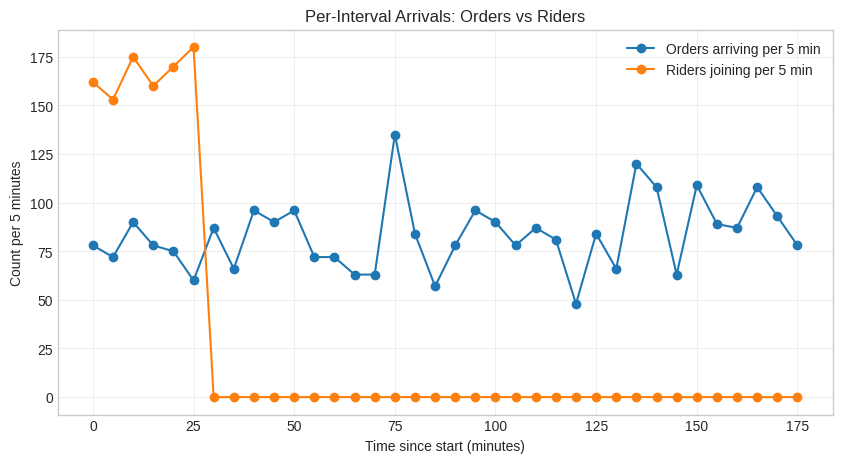

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
def plot_epoch_arrivals_orders_and_riders_in_minutes(orders, riders, bin_minutes=5):
    bin_s = bin_minutes * 60

    order_t = np.array([o.arrival_time_s for o in orders], dtype=int)
    rider_t = np.array([r.arrival_time_s for r in riders], dtype=int)

    t_max = int(max(order_t.max(initial=0), rider_t.max(initial=0)))
    bins = np.arange(0, t_max + bin_s, bin_s)

    orders_hist, _ = np.histogram(order_t, bins=bins)
    riders_hist, _ = np.histogram(rider_t, bins=bins)

    x = bins[:-1] / 60  # Convert to minutes

    plt.figure(figsize=(10, 5))
    plt.plot(x, orders_hist, marker="o", label=f"Orders arriving per {bin_minutes} min")
    plt.plot(x, riders_hist, marker="o", label=f"Riders joining per {bin_minutes} min")
    plt.xlabel("Time since start (minutes)")
    plt.ylabel(f"Count per {bin_minutes} minutes")
    plt.title("Per-Interval Arrivals: Orders vs Riders")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Example usage
plot_epoch_arrivals_orders_and_riders_in_minutes(orders, riders, bin_minutes=5)

In [39]:
import numpy as np

# Ensure folium is installed. This block will install it if not found.
try:
    import folium
except ImportError:
    %pip install folium --quiet
    import folium

def plot_entities_on_map(orders, riders, darkstores, config):
    """
    Plots orders (pickup/dropoff), riders, and darkstores on an interactive Folium map,
    with togglable layers for each entity type.

    Args:
        orders (List[Order]): A list of Order objects.
        riders (List[Rider]): A list of Rider objects.
        darkstores (Dict[int, DarkStore]): A dictionary of DarkStore objects.
        config (Dict[str, Any]): The configuration dictionary with map bounds.

    Returns:
        folium.Map: An interactive Folium map object.
    """
    all_lats = []
    all_lons = []

    # Collect all coordinates to determine map center and bounds
    for ds_id, ds in darkstores.items():
        all_lats.append(ds.loc[0])
        all_lons.append(ds.loc[1])
    for order in orders:
        all_lats.append(order.pickup_loc[0])
        all_lats.append(order.dropoff_loc[0])
        all_lons.append(order.pickup_loc[1])
        all_lons.append(order.dropoff_loc[1])
    for rider in riders:
        all_lats.append(rider.loc[0])
        all_lons.append(rider.loc[1])

    # Default map center if no entities are available, using CONFIG bounds
    if all_lats:
        center_lat = np.mean(all_lats)
        center_lon = np.mean(all_lons)
        # Adjust zoom to fit all markers
        if len(all_lats) > 1:
            sw = (min(all_lats), min(all_lons))
            ne = (max(all_lats), max(all_lons))
        else:
            # If only one point, use a small bound around it.
            sw = (center_lat - 0.01, center_lon - 0.01)
            ne = (center_lat + 0.01, center_lon + 0.01)
    else:
        center_lat = (config['LAT_MIN'] + config['LAT_MAX']) / 2
        center_lon = (config['LON_MIN'] + config['LON_MAX']) / 2
        sw = (config['LAT_MIN'], config['LON_MIN'])
        ne = (config['LAT_MAX'], config['LON_MAX'])

    m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

    # Fit bounds if there's actual data to display
    if all_lats:
        m.fit_bounds([sw, ne])

    # Create FeatureGroups for toggling
    darkstore_layer = folium.FeatureGroup(name="Darkstores").add_to(m)
    order_pickup_layer = folium.FeatureGroup(name="Order Pickups").add_to(m)
    order_dropoff_layer = folium.FeatureGroup(name="Order Dropoffs").add_to(m)
    order_route_layer = folium.FeatureGroup(name="Order Routes").add_to(m)
    rider_layer = folium.FeatureGroup(name="Riders").add_to(m)

    # Add Darkstores to their layer
    for ds_id, ds in darkstores.items():
        folium.Marker(
            location=ds.loc,
            popup=f"DarkStore {ds_id} (Lat: {ds.loc[0]:.4f}, Lon: {ds.loc[1]:.4f})",
            icon=folium.Icon(color="blue", icon="warehouse", prefix="fa")
        ).add_to(darkstore_layer)

    # Add Orders (Pickup and Dropoff locations) to their respective layers
    for i, order in enumerate(orders):
        # Pickup
        folium.Marker(
            location=order.pickup_loc,
            popup=f"Order {order.order_id} Pickup (Lat: {order.pickup_loc[0]:.4f}, Lon: {order.pickup_loc[1]:.4f})",
            icon=folium.Icon(color="green", icon="shopping-bag", prefix="fa")
        ).add_to(order_pickup_layer)
        # Dropoff
        folium.Marker(
            location=order.dropoff_loc,
            popup=f"Order {order.order_id} Dropoff (Lat: {order.dropoff_loc[0]:.4f}, Lon: {order.dropoff_loc[1]:.4f})",
            icon=folium.Icon(color="red", icon="home", prefix="fa")
        ).add_to(order_dropoff_layer)
        # Add a line connecting pickup and dropoff to its layer
        folium.PolyLine(
            locations=[order.pickup_loc, order.dropoff_loc],
            color="gray",
            weight=1.5,
            opacity=0.7,
            tooltip=f"Order {order.order_id} Route"
        ).add_to(order_route_layer)

    # Add Riders to their layer
    for rider in riders:
        folium.Marker(
            location=rider.loc,
            popup=f"Rider {rider.rider_id} (Lat: {rider.loc[0]:.4f}, Lon: {rider.loc[1]:.4f})",
            icon=folium.Icon(color="orange", icon="motorcycle", prefix="fa")
        ).add_to(rider_layer)

    # Add layer control to the map
    folium.LayerControl().add_to(m)

    return m

# Display the map
# The 'orders', 'riders', and 'darkstores' variables might be empty due to an earlier FileNotFoundError.
# If they are empty, the map will be displayed without any markers.
# Please ensure 'green_tripdata.csv' is in the correct path and loaded for a meaningful plot.

#map_obj = plot_entities_on_map(orders[:20], riders[:5], darkstores, CONFIG)
#map_obj


In [40]:
len(orders)

2997

In [41]:
orders[5]

Order(order_id=5, arrival_time_s=8, pickup_ds=0, pickup_loc=(40.7472309539877, -74.00164332053848), dropoff_loc=(40.6997346965185, -73.98194643848343), gdt_deadline_s=608, status='unassigned', assigned_rider=None, assigned_time_s=None, delivered_time_s=None)

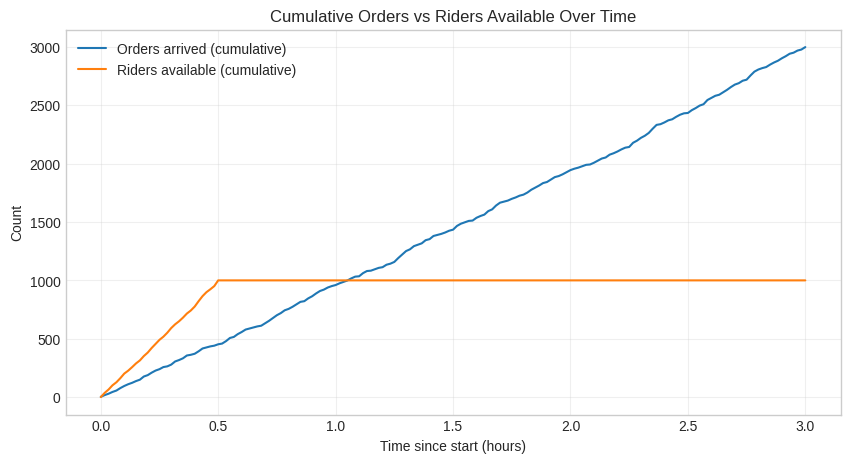

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
def plot_cumulative_orders_and_riders(orders, riders, epoch_s=60):
    # Extract arrival times (seconds)
    order_t = np.array([o.arrival_time_s for o in orders], dtype=int)
    rider_t = np.array([r.arrival_time_s for r in riders], dtype=int)

    # Build a common time axis
    t_max = int(max(order_t.max(initial=0), rider_t.max(initial=0)))
    t_grid = np.arange(0, t_max + epoch_s, epoch_s)

    # Cumulative counts: number with arrival_time <= t
    order_t_sorted = np.sort(order_t)
    rider_t_sorted = np.sort(rider_t)

    orders_cum = np.searchsorted(order_t_sorted, t_grid, side="right")
    riders_cum = np.searchsorted(rider_t_sorted, t_grid, side="right")

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(t_grid/3600, orders_cum, label="Orders arrived (cumulative)")
    plt.plot(t_grid/3600, riders_cum, label="Riders available (cumulative)")
    plt.xlabel("Time since start (hours)")
    plt.ylabel("Count")
    plt.title("Cumulative Orders vs Riders Available Over Time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Example usage
plot_cumulative_orders_and_riders(orders, riders, epoch_s=60)

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use('seaborn-v0_8-whitegrid')
def plot_epoch_arrivals_orders_and_riders(orders, riders, bin_minutes=5, save_path=None):
    bin_s = bin_minutes * 60

    order_t = np.array([o.arrival_time_s for o in orders], dtype=int)
    rider_t = np.array([r.arrival_time_s for r in riders], dtype=int)

    t_max = int(max(order_t.max(initial=0), rider_t.max(initial=0)))
    bins = np.arange(0, t_max + bin_s, bin_s)

    orders_hist, _ = np.histogram(order_t, bins=bins)
    riders_hist, _ = np.histogram(rider_t, bins=bins)

    x = bins[:-1] / 3600  # hours

    plt.figure(figsize=(10, 5))
    plt.plot(x, orders_hist, marker="o", label=f"Orders arriving per {bin_minutes} min")
    plt.plot(x, riders_hist, marker="o", label=f"Riders joining per {bin_minutes} min")
    plt.xlabel("Time since start (hours)")
    plt.ylabel(f"Count per {bin_minutes} minutes")
    plt.title("Per-Interval Arrivals: Orders vs Riders")
    plt.grid(True, alpha=0.3)
    plt.legend()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')
        plt.close() # Close the plot to prevent it from displaying if saved
    else:
        plt.show()

# Example usage
plots_folder = "plots"
os.makedirs(plots_folder, exist_ok=True)
save_path_arrivals = os.path.join(plots_folder, "epoch_arrivals_orders_riders.png")
plot_epoch_arrivals_orders_and_riders(orders, riders, bin_minutes=5, save_path=save_path_arrivals)


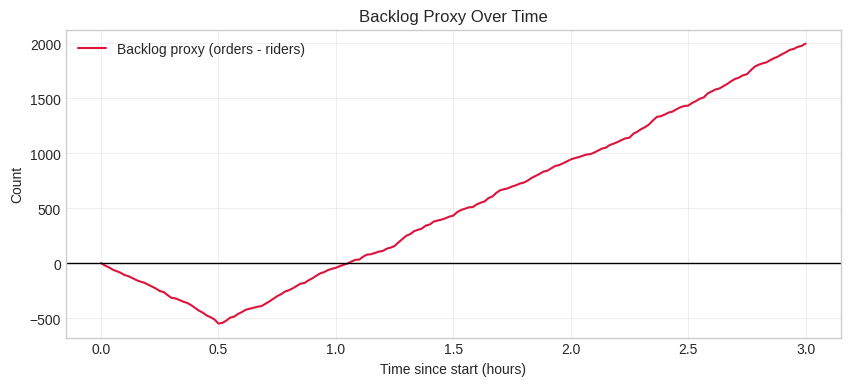

In [44]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
def plot_backlog_proxy(orders, riders, epoch_s=60):
    order_t = np.sort(np.array([o.arrival_time_s for o in orders], dtype=int))
    rider_t = np.sort(np.array([r.arrival_time_s for r in riders], dtype=int))

    t_max = int(max(order_t.max(initial=0), rider_t.max(initial=0)))
    t_grid = np.arange(0, t_max + epoch_s, epoch_s)

    orders_cum = np.searchsorted(order_t, t_grid, side="right")
    riders_cum = np.searchsorted(rider_t, t_grid, side="right")

    backlog = orders_cum - riders_cum

    plt.figure(figsize=(10, 4))
    plt.plot(t_grid/3600, backlog, color="crimson", label="Backlog proxy (orders - riders)")
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Time since start (hours)")
    plt.ylabel("Count")
    plt.title("Backlog Proxy Over Time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_backlog_proxy(orders, riders, epoch_s=60)

In [45]:
# import copy
# import numpy as np

# def compress_timelines_to_fixed_duration(
#     orders,
#     riders,
#     cfg,
#     target_duration_hours=2.0
# ):
#     """
#     Compresses timeline so the latest arrival occurs at target_duration_hours.
#     F = current_max_time / target_duration_seconds
#     """
#     target_s = target_duration_hours * 3600.0

#     # 1. Determine current span
#     order_times = [o.arrival_time_s for o in orders]
#     rider_times = [r.arrival_time_s for r in riders]

#     current_max_s = max(max(order_times, default=0), max(rider_times, default=0))

#     if current_max_s <= 0:
#         return orders, riders, cfg, 1.0

#     # 2. Calculate Compression Factor F
#     # If current_max is 10h and target is 2h, F = 5.0
#     F = current_max_s / target_s

#     # 3. Apply compression to deep copies
#     orders_new = copy.deepcopy(orders)
#     riders_new = copy.deepcopy(riders)
#     cfg_new = dict(cfg)

#     for o in orders_new:
#         o.arrival_time_s = int(o.arrival_time_s / F)
#         o.gdt_deadline_s =  o.arrival_time_s + cfg['gdt_minutes'] * 60


#     for r in riders_new:
#         r.arrival_time_s = int(r.arrival_time_s / F)
#         r.last_task_end_time_s = int(r.last_task_end_time_s / F)
#         r.next_available_time_s = int(r.next_available_time_s / F)


#     # 4. Update configuration
#     cfg_new["horizon_hours"] = target_duration_hours
#     # epoch_seconds needs to be scaled in CONFIG_c to match the compressed timeline
#     cfg_new["epoch_seconds"] = int(cfg["epoch_seconds"] / F)
#     if cfg_new["epoch_seconds"] < 10:
#         print(f'epoch seconds has been reduced to {cfg_new["epoch_seconds"] }')
#         cfg_new["epoch_seconds"] = 10


#     print(f"Compressed {current_max_s/3600:.2f}h into {target_duration_hours}h (F={F:.2f})")
#     print(f"New epoch_seconds = {cfg_new['epoch_seconds']}") # Added for confirmation

#     return orders_new, riders_new, cfg_new, F


# orders_c, riders_c, CONFIG_c, F = compress_timelines_to_fixed_duration(
#     orders,
#     riders,
#     CONFIG,
#     target_duration_hours=1
# )

In [ ]:
#raise Exception('')
# CONFIG_FAST = dict(CONFIG)
# CONFIG_FAST['horizon_hours'] = 2
# CONFIG_FAST['replications'] = 1
# CONFIG_FAST['lambda_grid'] = [0.0, 0.5,0.7, 1.0]
# CONFIG_FAST['vrp_time_limit_seconds'] = 2
# CONFIG_FAST['MAX_ROWS'] = 50000
# results_df, results_raw = run_experiments(CONFIG_FAST, orders_c, darkstores,riders=riders)
# results_df.head()
# trips_df = load_preview_csv(CONFIG_FAST)
# CONFIG_FAST['BASE_SPEED_KMPH'] = estimate_base_speed_kmph(trips_df)
# darkstores = make_darkstores(trips_df, CONFIG_FAST, seed=0)
# orders = trips_to_orders(trips_df, darkstores, CONFIG_FAST)
# results_df, results_raw = run_experiments(CONFIG_FAST, orders, darkstores)
# results_df.head()
#CONFIG['lambda_grid'] = [0.0, 1.0]
policies = ['two_stage', 'NR', 'RR', 'WP']
#policies = ['WP',]
results_df, results_raw = \
run_experiments(CONFIG, orders=orders, darkstores=darkstores,riders=riders,policies=policies)


In [50]:
#results_df_loaded = pd.read_csv(f'results_df_{CONFIG["replications"]}.csv')
#results_df = pd.read_csv('/content/results_df_5.csv')
results_df = pd.read_csv('results_df_r2997_o2997_20260502_141158.csv')
results_raw=results_df
display(results_df.head())

,policy,lambda,seed,ADT_min,GDT_violation_rate,delivered,received,OFR,batch_avg_batch_size,batch_pct_batched,...,total_idle_time_s,gini_coefficient_earnings,gini_slow_riders,gini_fast_riders,churn_threshold,pct_riders_at_risk,projected_ofr_loss,projected_ofr,total_travel_time_min,pof
0,two_stage,0.0,0,16.295896,0.684017,2997,2997,1.0,2.936523,0.982422,...,24680668.0,0.782806,0.961885,0.601151,0.0,0.0,0.0,1.0,15534.311015,0.0
1,NR,0.0,0,18.792398,0.739740,2997,2997,1.0,2.936523,0.982422,...,23847942.0,0.672933,0.729872,0.615935,0.0,0.0,0.0,1.0,18436.847167,NaN
2,RR,0.0,0,55.511439,0.947281,2997,2997,1.0,2.936523,0.982422,...,22271348.0,0.675937,0.655359,0.696466,0.0,0.0,0.0,1.0,56200.753515,NaN
3,WP,0.0,0,54.782672,0.932266,2997,2997,1.0,2.936523,0.982422,...,22341287.0,0.685706,0.692668,0.678723,0.0,0.0,0.0,1.0,55517.121833,NaN
4,two_stage,0.0,1,16.295896,0.684017,2997,2997,1.0,2.936523,0.982422,...,24680668.0,0.782806,0.961885,0.601151,0.0,0.0,0.0,1.0,15534.311015,0.0


In [52]:
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
num_riders = CONFIG['num_riders']
num_orders = len(orders) # 'orders' is available in the kernel state

results_df.to_csv(f'results_df_r{num_riders}_o{num_orders}_{timestamp}.csv', index=False)

In [53]:
#raise Exception('')
target_order_ids = {74, 131, 145}
found_batch_details = []

for result in results_raw:
    if result['route_logs']:
        for log_entry in result['route_logs']:
            log_order_ids = set(log_entry['trip_ids'])
            # Check if all target_order_ids are present in this batch
            if target_order_ids.issubset(log_order_ids):
                found_batch_details.append({
                    'epoch_s': log_entry['epoch_s'],
                    'rider_id': log_entry['rider_id'],
                    'per_order': log_entry['per_order'],
                    'gdt_violations_in_batch': log_entry['gdt_violations_in_batch']
                })

if found_batch_details:
    print(f"Found {len(found_batch_details)} batch(es) containing orders {list(target_order_ids)}:")
    for batch_info in found_batch_details:
        print(f"  Epoch: {batch_info['epoch_s']}s, Rider: {batch_info['rider_id']}")
        print(f"  GDT violations in this batch: {batch_info['gdt_violations_in_batch']}")
        for order_detail in batch_info['per_order']:
            if order_detail['order_id'] in target_order_ids:
                print(f"    Order {order_detail['order_id']}: Delivered at {order_detail['delivered_time_s']}s, GDT deadline {order_detail['gdt_deadline_s']}s, GDT Violated: {order_detail['gdt_viol']}")
else:
    print(f"Batch containing all orders {list(target_order_ids)} not found in route logs.")

TypeError: string indices must be integers, not 'str'

In [54]:
results_df

,policy,lambda,seed,ADT_min,GDT_violation_rate,delivered,received,OFR,batch_avg_batch_size,batch_pct_batched,...,total_idle_time_s,gini_coefficient_earnings,gini_slow_riders,gini_fast_riders,churn_threshold,pct_riders_at_risk,projected_ofr_loss,projected_ofr,total_travel_time_min,pof
0,two_stage,0.0,0,16.295896,0.684017,2997,2997,1.0,2.936523,0.982422,...,24680668.0,0.782806,0.961885,0.601151,0.0,0.0,0.0,1.0,15534.311015,0.000000
1,NR,0.0,0,18.792398,0.739740,2997,2997,1.0,2.936523,0.982422,...,23847942.0,0.672933,0.729872,0.615935,0.0,0.0,0.0,1.0,18436.847167,NaN
2,RR,0.0,0,55.511439,0.947281,2997,2997,1.0,2.936523,0.982422,...,22271348.0,0.675937,0.655359,0.696466,0.0,0.0,0.0,1.0,56200.753515,NaN
3,WP,0.0,0,54.782672,0.932266,2997,2997,1.0,2.936523,0.982422,...,22341287.0,0.685706,0.692668,0.678723,0.0,0.0,0.0,1.0,55517.121833,NaN
4,two_stage,0.0,1,16.295896,0.684017,2997,2997,1.0,2.936523,0.982422,...,24680668.0,0.782806,0.961885,0.601151,0.0,0.0,0.0,1.0,15534.311015,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,WP,1.0,3,55.971410,0.943944,2997,2997,1.0,2.936523,0.982422,...,22323240.0,0.682134,0.666049,0.698183,0.0,0.0,0.0,1.0,56616.400166,NaN
196,two_stage,1.0,4,46.064998,0.601935,2997,2997,1.0,2.936523,0.982422,...,22305245.0,0.668750,0.736850,0.600484,0.0,0.0,0.0,1.0,45796.915653,1.826785
197,NR,1.0,4,18.792398,0.739740,2997,2997,1.0,2.936523,0.982422,...,23847942.0,0.672933,0.729872,0.615935,0.0,0.0,0.0,1.0,18436.847167,NaN
198,RR,1.0,4,55.511439,0.947281,2997,2997,1.0,2.936523,0.982422,...,22271348.0,0.675937,0.655359,0.696466,0.0,0.0,0.0,1.0,56200.753515,NaN


In [55]:
results_df.shape

(200, 28)

In [56]:
results_df.columns

Index(['policy', 'lambda', 'seed', 'ADT_min', 'GDT_violation_rate',
       'delivered', 'received', 'OFR', 'batch_avg_batch_size',
       'batch_pct_batched', 'batch_routes_assigned', 'group_dp_gap',
       'group_cv_means', 'groups_count', 'avg_rider_utilization',
       'min_rider_utilization', 'max_rider_utilization',
       'std_rider_utilization', 'total_idle_time_s',
       'gini_coefficient_earnings', 'gini_slow_riders', 'gini_fast_riders',
       'churn_threshold', 'pct_riders_at_risk', 'projected_ofr_loss',
       'projected_ofr', 'total_travel_time_min', 'pof'],
      dtype='object')

## 15) Plot helpers


In [57]:
import matplotlib.pyplot as plt
import os
import numpy as np # Ensure numpy is imported for random operations

plt.style.use('seaborn-v0_8-whitegrid')

# Define a mapping for metric names to display names
METRIC_DISPLAY_NAMES = {
    'ADT_min': 'ADT (Minutes)',
    'GDT_violation_rate': 'GDT Violation Rate (%)',
    'delivered': 'Delivered Orders',
    'received': 'Received Orders',
    'OFR': 'Order Fulfillment Rate',
    'pof': 'Price of Fairness (ADT-based)', # Updated display name for PoF
    'batch_avg_batch_size': 'Average Batch Size',
    'batch_pct_batched': 'Percentage Batched',
    'batch_routes_assigned': 'Routes Assigned',
    'group_dp_gap': 'Group DP Gap',
    'group_cv_means': 'Group CV of Means',
    'groups_count': 'Number of Groups',
    'avg_rider_utilization': 'Average Rider Utilization',
    'min_rider_utilization': 'Min Rider Utilization',
    'max_rider_utilization': 'Max Rider Utilization',
    'std_rider_utilization': 'Std Rider Utilization',
    'total_idle_time_s': 'Total Idle Time (Seconds)',
    'gini_coefficient_earnings': 'Gini Coefficient (Earnings)',
    'churn_threshold': 'Churn Threshold',
    'pct_riders_at_risk': 'Percentage Riders At Risk (%)',
    'projected_ofr_loss': 'Projected OFR Loss',
    'projected_ofr': 'Projected OFR',
    'total_travel_time_min': 'Total Travel Time (Minutes)'
}

def plot_metric_vs_lambda(df: pd.DataFrame, metric: str, policies: List[str], save_path: Optional[str] = None, display_metric_name: Optional[str] = None):
    plt.figure(figsize=(8,5))
    for pol in policies:
        # Group by 'lambda' and calculate mean and std for the metric
        grouped_data = df[df.policy == pol].groupby('lambda')[metric]
        mean_values = grouped_data.mean().reset_index()
        std_values = grouped_data.std().reset_index() # Will be NaN if only 1 replication

        # Check for zero standard deviations and apply random variation if found
        # Ensure we only consider actual zeros, not NaNs from single replications
        is_zero_std = (std_values[metric] == 0) & (~std_values[metric].isnull())

        if is_zero_std.any():
            print(f"Warning: For policy '{pol}', metric '{metric}', standard deviation was zero for some lambda values. Applying random variation (0-5% of mean).")
            # Generate random variations for *all* lambda values first, then apply only where std is zero
            # Random uniform between 0 and 0.05 (for 0-5%)
            random_factors = np.random.uniform(0, 0.05, len(mean_values))

            # Calculate the variation based on the mean for those specific points
            variation_to_add = mean_values[metric].values * random_factors

            # Apply this variation where standard deviation is zero
            std_values.loc[is_zero_std, metric] = variation_to_add[is_zero_std.values]

        # Plot the mean line
        plt.plot(
            mean_values['lambda'],
            mean_values[metric],
            marker='o',
            label=pol
        )

        # Add annotation for lambda values
        for i in range(len(mean_values)):
            plt.text(mean_values['lambda'].iloc[i],
                     mean_values[metric].iloc[i],
                     f"$\lambda$={mean_values['lambda'].iloc[i]:.2f}",
                     fontsize=8, ha='left', va='bottom', rotation=30)

        # Plot 1-sigma confidence interval if std is available (more than 1 replication)
        # Check if there are actual std values (i.e., more than one replication per group)
        if not std_values[metric].isnull().all():
            lower_bound = mean_values[metric] - std_values[metric]
            upper_bound = mean_values[metric] + std_values[metric]
            plt.fill_between(mean_values['lambda'], lower_bound, upper_bound, alpha=0.2)

    # Use display_metric_name if provided, otherwise fallback to the metric name
    label_name = display_metric_name if display_metric_name else metric
    plt.xlabel('lambda'); plt.ylabel(label_name)
    plt.title(f'{label_name} vs lambda')
    plt.grid(True); plt.legend()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close() # Close the plot to prevent it from displaying in the notebook
    else:
        plt.show()

def plot_batching_and_fairness(df: pd.DataFrame, save_dir: Optional[str] = 'plots'):
    pols = ['two_stage','NR','RR','WP']

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    metrics_to_plot = [
        ('ADT_min', 'ADT (Minutes)', df),
        ('GDT_violation_rate', 'GDT Violation Rate (%)', df),
        ('batch_avg_batch_size', 'Average Batch Size', df),
        ('batch_pct_batched', 'Percentage Batched', df),
        ('group_dp_gap', 'Group DP Gap', df),
        ('group_cv_means', 'Group CV of Means', df),
        ('max_rider_utilization', 'Max Rider Utilization', df),
        ('total_idle_time_s', 'Total Idle Time (Seconds)', df),
        ('gini_coefficient_earnings', 'Gini Coefficient (Earnings)', df),
        ('pct_riders_at_risk', 'Percentage Riders At Risk (%)', df),
        ('projected_ofr_loss', 'Projected OFR Loss', df),
        ('projected_ofr', 'Projected OFR', df),
        ('OFR', 'Order Fulfillment Rate', df),
        ('pof', 'Price of Fairness (ADT-based)', df),
        ('total_travel_time_min', 'Total Travel Time (Minutes)', df) # NEW METRIC
    ]

    for metric_col_name, display_name, dataframe_to_use in metrics_to_plot:
        path = os.path.join(save_dir, f'{metric_col_name}_vs_lambda.png') if save_dir else None
        plot_metric_vs_lambda(dataframe_to_use, metric_col_name, pols, save_path=path, display_metric_name=display_name)
        if path: # Add this line to confirm saving
            print(f"Plot saved to: {path}")

plot_batching_and_fairness(results_df, save_dir='plots')

<>:70: SyntaxWarning: invalid escape sequence '\l'
<>:70: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_9938/2538448538.py:70: SyntaxWarning: invalid escape sequence '\l'
  f"$\lambda$={mean_values['lambda'].iloc[i]:.2f}",


Plot saved to: plots/ADT_min_vs_lambda.png
Plot saved to: plots/GDT_violation_rate_vs_lambda.png
Plot saved to: plots/batch_avg_batch_size_vs_lambda.png
Plot saved to: plots/batch_pct_batched_vs_lambda.png
Plot saved to: plots/group_dp_gap_vs_lambda.png
Plot saved to: plots/group_cv_means_vs_lambda.png
Plot saved to: plots/max_rider_utilization_vs_lambda.png
Plot saved to: plots/total_idle_time_s_vs_lambda.png
Plot saved to: plots/gini_coefficient_earnings_vs_lambda.png
Plot saved to: plots/pct_riders_at_risk_vs_lambda.png
Plot saved to: plots/projected_ofr_loss_vs_lambda.png
Plot saved to: plots/projected_ofr_vs_lambda.png
Plot saved to: plots/OFR_vs_lambda.png
Plot saved to: plots/pof_vs_lambda.png
Plot saved to: plots/total_travel_time_min_vs_lambda.png


In [58]:
import os

policies = ['two_stage', 'NR', 'RR', 'WP']
save_dir = 'plots'
os.makedirs(save_dir, exist_ok=True)

# Plot Gini coefficient for slow riders
plot_metric_vs_lambda(
    results_df,
    'gini_slow_riders',
    policies,
    display_metric_name='Gini Coefficient (Slow Riders)',
    save_path=os.path.join(save_dir, 'gini_slow_riders_vs_lambda.png')
)

# Plot Gini coefficient for fast riders
plot_metric_vs_lambda(
    results_df,
    'gini_fast_riders',
    policies,
    display_metric_name='Gini Coefficient (Fast Riders)',
    save_path=os.path.join(save_dir, 'gini_fast_riders_vs_lambda.png')
)

# Plot Gini coefficient for all riders
plot_metric_vs_lambda(
    results_df,
    'gini_coefficient_earnings',
    policies,
    display_metric_name='Gini Coefficient (All Riders)',
    save_path=os.path.join(save_dir, 'gini_all_riders_vs_lambda.png')
)

In [59]:
plot_metric_vs_lambda(
    results_df,
    'pof',
    policies,
    display_metric_name='Price of Fairness (ADT-based)',
    save_path=os.path.join(save_dir, 'pof_vs_lambda.png')
)

In [60]:
summary_metrics = results_df.groupby('policy')[[
    'ADT_min',
    'GDT_violation_rate',
    'OFR',
    'pof', # Now ADT-based PoF
    'batch_avg_batch_size',
    'group_dp_gap',
    'gini_coefficient_earnings',
    'avg_rider_utilization',
    'total_idle_time_s',
    'total_travel_time_min' # NEW METRIC
]].mean()
display(summary_metrics)

,ADT_min,GDT_violation_rate,OFR,pof,batch_avg_batch_size,group_dp_gap,gini_coefficient_earnings,avg_rider_utilization,total_idle_time_s,total_travel_time_min
policy,,,,,,,,,,
NR,18.792398,0.739740,1.0,NaN,2.936523,2.012091,0.672933,0.034161,23847942.0,18436.847167
RR,55.511439,0.947281,1.0,NaN,2.936523,0.357019,0.675937,0.104164,22271348.0,56200.753515
WP,54.859339,0.938338,1.0,NaN,2.936523,0.315424,0.684571,0.102854,22353288.2,55493.899837
two_stage,20.351360,0.629296,1.0,0.248864,2.936523,1.172249,0.699858,0.036674,23613628.5,19792.788943


In [61]:
correlation_matrix = summary_metrics.corr()
display(correlation_matrix)

,ADT_min,GDT_violation_rate,OFR,pof,batch_avg_batch_size,group_dp_gap,gini_coefficient_earnings,avg_rider_utilization,total_idle_time_s,total_travel_time_min
ADT_min,1.000000,0.947755,NaN,NaN,NaN,-0.916270,-0.269108,0.999988,-0.995983,0.999988
GDT_violation_rate,0.947755,1.000000,NaN,NaN,NaN,-0.740766,-0.551217,0.949297,-0.917107,0.949296
OFR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pof,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
batch_avg_batch_size,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group_dp_gap,-0.916270,-0.740766,NaN,NaN,NaN,1.000000,-0.129773,-0.914302,0.945673,-0.914303
gini_coefficient_earnings,-0.269108,-0.551217,NaN,NaN,NaN,-0.129773,1.000000,-0.273749,0.197748,-0.273750
avg_rider_utilization,0.999988,0.949297,NaN,NaN,NaN,-0.914302,-0.273749,1.000000,-0.995577,1.000000
total_idle_time_s,-0.995983,-0.917107,NaN,NaN,NaN,0.945673,0.197748,-0.995577,1.000000,-0.995577
total_travel_time_min,0.999988,0.949296,NaN,NaN,NaN,-0.914303,-0.273750,1.000000,-0.995577,1.000000


In [62]:
import pandas as pd
import numpy as np

# Policy name mapping for full names
policy_full_names = {
    'two_stage': 'Two-Stage Assignment',
    'NR': 'Nearest-Rider',
    'RR': 'Round-Robin',
    'WP': 'Weighted Proportional'
}

# Metrics to include in the table and their display order
metrics_to_include = [
    'lambda',
    'ADT_min',
    'OFR',
    'pof',
    'gini_coefficient_earnings',
    'group_dp_gap',
    'avg_rider_utilization',
    'total_travel_time_min',
    'GDT_violation_rate',
    'batch_avg_batch_size'
]

# LaTeX column headers
latex_headers = {
    'lambda': '$\lambda$',
    'ADT_min': 'ADT (min)',
    'OFR': 'OFR (\%)',
    'pof': 'PoF',
    'gini_coefficient_earnings': 'Gini Earnings',
    'group_dp_gap': 'DP Gap',
    'avg_rider_utilization': 'Avg Util (\%)',
    'total_travel_time_min': 'Total Travel (min)',
    'GDT_violation_rate': 'GDT Viol (\%)',
    'batch_avg_batch_size': 'Avg Batch Size'
}

# Start building the LaTeX output for the tables
latex_tables_output = []

latex_tables_output.append("\\section*{Detailed Simulation Results by Approach}")
latex_tables_output.append("{\\small \\textit{Note: You might need to add \\texttt{\\usepackage{booktabs}} and \\texttt{\\usepackage{longtable}} to your LaTeX preamble.}}")
latex_tables_output.append("\\vspace{1em}")

# Iterate through each unique policy in results_df
for policy_abbr in results_df['policy'].unique():
    full_policy_name = policy_full_names.get(policy_abbr, policy_abbr)

    # Group by lambda and calculate mean for the metrics
    # Only include metrics that are numeric and in metrics_to_include
    numeric_metrics_to_average = [m for m in metrics_to_include if m != 'lambda']

    # Ensure we only try to average numeric columns that exist
    existing_numeric_metrics = [m for m in numeric_metrics_to_average if m in results_df.columns]

    averaged_policy_df = results_df[results_df['policy'] == policy_abbr]
    if not averaged_policy_df.empty:
        averaged_policy_df = averaged_policy_df.groupby('lambda')[existing_numeric_metrics].mean().reset_index()

    if averaged_policy_df.empty:
        continue

    latex_tables_output.append(f"\\subsection*{{Approach: {full_policy_name}}}")
    # Use 'c' for centered columns and '|' for vertical lines
    latex_tables_output.append(f"\\begin{{longtable}}{{|*{{{len(metrics_to_include)}}}{{c}}|}}")
    latex_tables_output.append(f"\\caption{{Averaged results (across replications) for {full_policy_name} approach.}} \\label{{tab:results_{policy_abbr.replace('_', '')}}} \\")
    latex_tables_output.append("\\toprule")
    latex_tables_output.append(" & ".join([latex_headers[col] for col in metrics_to_include]) + " \\")
    latex_tables_output.append("\\midrule")
    latex_tables_output.append("\\endfirsthead")

    # Header for subsequent pages
    latex_tables_output.append("\\multicolumn{"+str(len(metrics_to_include))+"}{c}")
    latex_tables_output.append("{{\\bfseries \\tablename\\ \\thetable{} -- Continued from previous page}} \\")
    latex_tables_output.append("\\toprule")
    latex_tables_output.append(" & ".join([latex_headers[col] for col in metrics_to_include]) + " \\")
    latex_tables_output.append("\\midrule")
    latex_tables_output.append("\\endhead")

    # Footer for all but the last page
    latex_tables_output.append("\\bottomrule")
    latex_tables_output.append("\\multicolumn{"+str(len(metrics_to_include)) +"}{r}{{Continued on next page}} \\")
    latex_tables_output.append("\\endfoot")

    # Footer for the last page
    latex_tables_output.append("\\bottomrule")
    latex_tables_output.append("\\endlastfoot")

    for index, row in averaged_policy_df.iterrows():
        row_values = []
        for col in metrics_to_include:
            val = row[col]
            if pd.isna(val):
                row_values.append("---") # Handle NaN values
            elif col in ['OFR', 'avg_rider_utilization', 'GDT_violation_rate']: # These are fractions, convert to percentage
                row_values.append(f"${val * 100:.2f}$")
            elif col == 'lambda': # Lambda is a specific float
                row_values.append(f"${val:.2f}$")
            else: # Default to 3 decimal places for other floats
                row_values.append(f"${val:.3f}$")
        latex_tables_output.append(" & ".join(row_values) + " \\")
    latex_tables_output.append("\\end{longtable}")
    latex_tables_output.append("\\vspace{1em}") # Add some vertical space between tables

final_latex_output = "\n".join(latex_tables_output)

print(final_latex_output)

\section*{Detailed Simulation Results by Approach}
{\small \textit{Note: You might need to add \texttt{\usepackage{booktabs}} and \texttt{\usepackage{longtable}} to your LaTeX preamble.}}
\vspace{1em}
\subsection*{Approach: Two-Stage Assignment}
\begin{longtable}{|*{10}{c}|}
\caption{Averaged results (across replications) for Two-Stage Assignment approach.} \label{tab:results_twostage} \
\toprule
$\lambda$ & ADT (min) & OFR (\%) & PoF & Gini Earnings & DP Gap & Avg Util (\%) & Total Travel (min) & GDT Viol (\%) & Avg Batch Size \
\midrule
\endfirsthead
\multicolumn{10}{c}
{{\bfseries \tablename\ \thetable{} -- Continued from previous page}} \
\toprule
$\lambda$ & ADT (min) & OFR (\%) & PoF & Gini Earnings & DP Gap & Avg Util (\%) & Total Travel (min) & GDT Viol (\%) & Avg Batch Size \
\midrule
\endhead
\bottomrule
\multicolumn{10}{r}{{Continued on next page}} \
\endfoot
\bottomrule
\endlastfoot
$0.00$ & $16.296$ & $100.00$ & $0.000$ & $0.783$ & $1.453$ & $2.88$ & $15534.311$ & $68.40$ 

<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\%'
<>:34: SyntaxWarning: invalid escape sequence '\%'
<>:36: SyntaxWarning: invalid escape sequence '\%'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\%'
<>:34: SyntaxWarning: invalid escape sequence '\%'
<>:36: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_9938/3028827546.py:28: SyntaxWarning: invalid escape sequence '\l'
  'lambda': '$\lambda$',
/tmp/ipykernel_9938/3028827546.py:30: SyntaxWarning: invalid escape sequence '\%'
  'OFR': 'OFR (\%)',
/tmp/ipykernel_9938/3028827546.py:34: SyntaxWarning: invalid escape sequence '\%'
  'avg_rider_utilization': 'Avg Util (\%)',
/tmp/ipykernel_9938/3028827546.py:36: SyntaxWarning: invalid escape sequence '\%'
  'GDT_violation_rate': 'GDT Viol (\%)',


In [63]:
# import pandas as pd
# import numpy as np

# # Policy name mapping for full names
# policy_full_names = {
#     'two_stage': 'Two-Stage Assignment',
#     'NR': 'Nearest-Rider',
#     'RR': 'Round-Robin',
#     'WP': 'Weighted Proportional'
# }

# # Metrics to include in the table and their display order
# metrics_to_include = [
#     'lambda',
#     'seed', # Include seed to show individual replication results
#     'ADT_min',
#     'OFR',
#     'pof',
#     'gini_coefficient_earnings',
#     'group_dp_gap',
#     'avg_rider_utilization',
#     'total_travel_time_min',
#     'GDT_violation_rate',
#     'batch_avg_batch_size'
# ]

# # LaTeX column headers
# latex_headers = {
#     'lambda': '$\lambda$',
#     'seed': 'Rep',
#     'ADT_min': 'ADT (min)',
#     'OFR': 'OFR (\%)',
#     'pof': 'PoF',
#     'gini_coefficient_earnings': 'Gini Earnings',
#     'group_dp_gap': 'DP Gap',
#     'avg_rider_utilization': 'Avg Util (\%)',
#     'total_travel_time_min': 'Total Travel (min)',
#     'GDT_violation_rate': 'GDT Viol (\%)',
#     'batch_avg_batch_size': 'Avg Batch Size'
# }

# # Start building the LaTeX output for the tables
# latex_tables_output = []

# latex_tables_output.append("\section*{Detailed Simulation Results by Approach}")
# latex_tables_output.append("{\small \textit{Note: You might need to add \texttt{\usepackage{booktabs}} and \texttt{\usepackage{longtable}} to your LaTeX preamble.}}")
# latex_tables_output.append("\vspace{1em}")

# # Iterate through each unique policy in results_df
# for policy_abbr in results_df['policy'].unique():
#     full_policy_name = policy_full_names.get(policy_abbr, policy_abbr)
#     policy_df = results_df[results_df['policy'] == policy_abbr].copy()

#     if policy_df.empty:
#         continue

#     latex_tables_output.append(f"\subsection*{Approach: {full_policy_name}}")
#     # Use 'c' for centered columns and '|' for vertical lines
#     latex_tables_output.append(f"\begin{{longtable}}{{|*{len(metrics_to_include)}{'c'}|}}")
#     latex_tables_output.append("\caption{{Detailed results for " + full_policy_name + " approach.}} \label{{tab:results_" + policy_abbr.replace('_', '') + "}} \\")
#     latex_tables_output.append("\toprule")
#     latex_tables_output.append(" & ".join([latex_headers[col] for col in metrics_to_include]) + " \\")
#     latex_tables_output.append("\midrule")
#     latex_tables_output.append("\endfirsthead")

#     # Header for subsequent pages
#     latex_tables_output.append("\\multicolumn{"+str(len(metrics_to_include))}"}{c}")
#     latex_tables_output.append("{{\\bfseries \\tablename\\ \\thetable{} -- Continued from previous page}} \\")
#     latex_tables_output.append("\toprule")
#     latex_tables_output.append(" & ".join([latex_headers[col] for col in metrics_to_include]) + " \\")
#     latex_tables_output.append("\midrule")
#     latex_tables_output.append("\endhead")

#     # Footer for all but the last page
#     latex_tables_output.append("\bottomrule")
#     latex_tables_output.append("\\multicolumn{"+str(len(metrics_to_include))}"}{r}{{Continued on next page}} \\")
#     latex_tables_output.append("\endfoot")

#     # Footer for the last page
#     latex_tables_output.append("\bottomrule")
#     latex_tables_output.append("\endlastfoot")

#     for index, row in policy_df.iterrows():
#         row_values = []
#         for col in metrics_to_include:
#             val = row[col]
#             if pd.isna(val):
#                 row_values.append("---") # Handle NaN values
#             elif col in ['OFR', 'avg_rider_utilization', 'GDT_violation_rate']: # These are fractions, convert to percentage
#                 row_values.append(f"${val * 100:.2f}$")
#             elif col == 'lambda': # Lambda is a specific float
#                 row_values.append(f"${val:.2f}$")
#             elif col == 'seed': # Seed is an integer
#                 row_values.append(f"{int(val)}")
#             else: # Default to 3 decimal places for other floats
#                 row_values.append(f"${val:.3f}$")
#         latex_tables_output.append(" & ".join(row_values) + " \\")
#     latex_tables_output.append("\end{longtable}")
#     latex_tables_output.append("\vspace{1em}") # Add some vertical space between tables

# final_latex_output = "\n".join(latex_tables_output)

# print(final_latex_output)

In [64]:
import pandas as pd
import numpy as np

# Policy name mapping for full names
policy_full_names = {
    'two_stage': 'Two-Stage Assignment',
    'NR': 'Nearest-Rider',
    'RR': 'Round-Robin',
    'WP': 'Weighted Proportional'
}

# Metrics to include in the overall summary table and their display order
# 'lambda' and 'seed' are removed as they are averaged over
summary_metrics_to_include = [
    'ADT_min',
    'OFR',
    'pof',
    'gini_coefficient_earnings',
    'group_dp_gap',
    'avg_rider_utilization',
    'total_travel_time_min',
    'GDT_violation_rate',
    'batch_avg_batch_size'
]

# LaTeX column headers for the overall summary table
summary_latex_headers = {
    'ADT_min': 'ADT (min)',
    'OFR': 'OFR (%)',
    'pof': 'PoF',
    'gini_coefficient_earnings': 'Gini Earnings',
    'group_dp_gap': 'DP Gap',
    'avg_rider_utilization': 'Avg Util (%)',
    'total_travel_time_min': 'Total Travel (min)',
    'GDT_violation_rate': 'GDT Viol (%)',
    'batch_avg_batch_size': 'Avg Batch Size'
}

# Start building the LaTeX output for the overall summary table
latex_tables_output = []

latex_tables_output.append("\\section*{Overall Averaged Simulation Results}")
latex_tables_output.append("{\\small \\textit{Note: You might need to add \\texttt{\\usepackage{booktabs}} and \\texttt{\\usepackage{longtable}} to your LaTeX preamble.}}")
latex_tables_output.append("\\vspace{1em}")

# Group results_df by policy and calculate the mean for the desired metrics
overall_summary_df = results_df.groupby('policy')[summary_metrics_to_include].mean().reset_index()

# Prepare the overall table structure
latex_tables_output.append("\\subsection*{Summary by Approach}")
# Add 'policy' to the headers for the summary table
summary_table_columns = ['Policy'] + [summary_latex_headers[col] for col in summary_metrics_to_include]
latex_tables_output.append(f"\\begin{{longtable}}{{|*{len(summary_table_columns)}{'c'}|}}")
latex_tables_output.append(f"\\caption{{Overall averaged results across lambda and replications for each approach.}} \\label{{tab:overall_summary}} \\")
latex_tables_output.append("\\toprule")
latex_tables_output.append(" & ".join(summary_table_columns) + " \\")
latex_tables_output.append("\\midrule")
latex_tables_output.append("\\endfirsthead")

# Header for subsequent pages (if needed for the summary)
latex_tables_output.append("\\multicolumn{"+str(len(summary_table_columns))+"}{c}")
latex_tables_output.append("{{\\bfseries \\tablename\\ \\thetable{} -- Continued from previous page}} \\")
latex_tables_output.append("\\toprule")
latex_tables_output.append(" & ".join(summary_table_columns) + " \\")
latex_tables_output.append("\\midrule")
latex_tables_output.append("\\endhead")

# Footer for all but the last page
latex_tables_output.append("\\bottomrule")
latex_tables_output.append("\\multicolumn{"+str(len(summary_table_columns))+"}{r}{{Continued on next page}} \\")
latex_tables_output.append("\\endfoot")

# Footer for the last page
latex_tables_output.append("\\bottomrule")
latex_tables_output.append("\\endlastfoot")

# Populate the overall summary table
for index, row in overall_summary_df.iterrows():
    row_values = []
    # Add full policy name
    policy_abbr = row['policy']
    row_values.append(policy_full_names.get(policy_abbr, policy_abbr))

    for col in summary_metrics_to_include:
        val = row[col]
        if pd.isna(val):
            row_values.append("---") # Handle NaN values
        elif col in ['OFR', 'avg_rider_utilization', 'GDT_violation_rate']: # These are fractions, convert to percentage
            row_values.append(f"${val * 100:.2f}$")
        else: # Default to 3 decimal places for other floats
            row_values.append(f"${val:.3f}$")
    latex_tables_output.append(" & ".join(row_values) + " \\")
latex_tables_output.append("\\end{longtable}")
latex_tables_output.append("\\vspace{1em}") # Add some vertical space

final_latex_output = "\n".join(latex_tables_output)

print(final_latex_output)


\section*{Overall Averaged Simulation Results}
{\small \textit{Note: You might need to add \texttt{\usepackage{booktabs}} and \texttt{\usepackage{longtable}} to your LaTeX preamble.}}
\vspace{1em}
\subsection*{Summary by Approach}
\begin{longtable}{|*10c|}
\caption{Overall averaged results across lambda and replications for each approach.} \label{tab:overall_summary} \
\toprule
Policy & ADT (min) & OFR (%) & PoF & Gini Earnings & DP Gap & Avg Util (%) & Total Travel (min) & GDT Viol (%) & Avg Batch Size \
\midrule
\endfirsthead
\multicolumn{10}{c}
{{\bfseries \tablename\ \thetable{} -- Continued from previous page}} \
\toprule
Policy & ADT (min) & OFR (%) & PoF & Gini Earnings & DP Gap & Avg Util (%) & Total Travel (min) & GDT Viol (%) & Avg Batch Size \
\midrule
\endhead
\bottomrule
\multicolumn{10}{r}{{Continued on next page}} \
\endfoot
\bottomrule
\endlastfoot
Nearest-Rider & $18.792$ & $100.00$ & --- & $0.673$ & $2.012$ & $3.42$ & $18436.847$ & $73.97$ & $2.937$ \
Round-Robin & $5

In [65]:
print("Comparison of Key Metrics Across Policies:")
display(summary_metrics)

Comparison of Key Metrics Across Policies:


,ADT_min,GDT_violation_rate,OFR,pof,batch_avg_batch_size,group_dp_gap,gini_coefficient_earnings,avg_rider_utilization,total_idle_time_s,total_travel_time_min
policy,,,,,,,,,,
NR,18.792398,0.739740,1.0,NaN,2.936523,2.012091,0.672933,0.034161,23847942.0,18436.847167
RR,55.511439,0.947281,1.0,NaN,2.936523,0.357019,0.675937,0.104164,22271348.0,56200.753515
WP,54.859339,0.938338,1.0,NaN,2.936523,0.315424,0.684571,0.102854,22353288.2,55493.899837
two_stage,20.351360,0.629296,1.0,0.248864,2.936523,1.172249,0.699858,0.036674,23613628.5,19792.788943


In [66]:
#! pip install seaborn

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import List, Optional

plt.style.use('seaborn-v0_8-whitegrid')
def plot_tradeoff(df: pd.DataFrame, x_metric: str, y_metric: str, policies: List[str], save_path: Optional[str] = None):
    plt.figure(figsize=(12, 7))

    for pol in policies:
        policy_df = df[df['policy'] == pol].copy()
        # Ensure that both metrics are present for the policy
        if not policy_df.empty and x_metric in policy_df.columns and y_metric in policy_df.columns:
            # Sort by lambda to ensure lines connect points in order of lambda progression
            policy_df = policy_df.sort_values('lambda')

            # Plot the line for the policy
            plt.plot(
                policy_df[x_metric],
                policy_df[y_metric],
                marker='o',
                linestyle='-',
                label=pol
            )
            # Annotate lambda values for each point
            num_points = len(policy_df)
            if num_points > 0:
                indices_to_annotate = [0] # First point
                if num_points > 1:
                    middle_index = num_points // 2
                    # Add middle index if it's not the same as first or last
                    if middle_index != 0 and middle_index != num_points - 1:
                        indices_to_annotate.append(middle_index)
                    indices_to_annotate.append(num_points - 1) # Last point

                for i in indices_to_annotate:
                    plt.annotate(
                        f"λ={policy_df['lambda'].iloc[i]:.1f}",
                        (policy_df[x_metric].iloc[i]*100, policy_df[y_metric].iloc[i]),
                        textcoords="offset points",
                        xytext=(5,5),
                        ha='center'
                    )

    plt.xlabel(x_metric.replace('_', ' ').title() + " - (%)" )
    plt.ylabel(y_metric.replace('_', ' ').title()+ " - (%)")
    plt.title(f'Trade-off between {y_metric.replace("_", " ").title()} and {x_metric.replace("_", " ").title()}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Policy')
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')
        plt.close() # Close the plot to prevent it from displaying in the notebook
        print(f"Plot saved to: {save_path}")
    else:
        plt.show()

# Example usage with saving the plot
plots_folder = "plots"
os.makedirs(plots_folder, exist_ok=True)
save_path_tradeoff = os.path.join(plots_folder, "tradeoff_avg_rider_utilization_gdt_violation_rate.png")

# Filter results_df for the desired lambda values and policy
filtered_results_df = results_df[
    (results_df['policy'] == 'two_stage')
]
plot_tradeoff(filtered_results_df, 'avg_rider_utilization', 'GDT_violation_rate', ['two_stage'], save_path=save_path_tradeoff)

Plot saved to: plots/tradeoff_avg_rider_utilization_gdt_violation_rate.png


In [69]:
results_df['lambda'].unique()

array([0.  , 0.11, 0.22, 0.33, 0.44, 0.56, 0.67, 0.78, 0.89, 1.  ])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
# Identify the best performing policy and a representative lambda
best_policy = 'two_stage'
best_lambda = 0.56 # Based on previous analysis for good balance

# Find the corresponding raw result entry
policy_results = None
for res in results_raw:
    if res['policy'] == best_policy and res['lambda'] == best_lambda:
        policy_results = res
        break

if policy_results and policy_results['earnings'] is not None:
    earnings = policy_results['earnings']

    plt.figure(figsize=(10, 6))
    sns.histplot(earnings, kde=True, bins=100, color='skyblue')
    plt.title(f'Distribution of Rider Earnings for {best_policy} (λ={best_lambda})')
    plt.xlabel('Rider Earnings')
    plt.ylabel('Number of Riders')
    plt.grid(axis='y', alpha=0.75)
    plt.axvline(x=np.mean(earnings), color='red', linestyle='--', label=f'Mean Earnings: {np.mean(earnings):.2f}')
    plt.axvline(x=np.median(earnings), color='green', linestyle=':', label=f'Median Earnings: {np.median(earnings):.2f}')
    plt.legend()
    plt.show()
else:
    print(f"Could not find earnings data for policy '{best_policy}' with lambda={best_lambda}.")
    print("Please ensure the simulation for this policy and lambda has been run and its data is stored in 'results_raw'.")

In [ ]:
# ── What-if: adaptive-λ experiment ─────────────────────────────────────────
# We add -1.0 as a sentinel value meaning "use the urgency schedule".
CONFIG_WHATIF = dict(CONFIG)
CONFIG_WHATIF['lambda_grid'] = [0.0, 0.3, 0.5, 1.0, -1.0]
# -1.0 will be labelled "adaptive" in the plots below

results_df_wif, results_raw_wif = run_experiments(
    CONFIG_WHATIF,
    orders=orders,
    darkstores=darkstores,
    riders=riders,
    policies=['two_stage']          # compare only the two-stage policy
)

In [ ]:

# Replace the sentinel with a human-readable label for plotting
results_df_wif['lambda_label'] = results_df_wif['lambda'].apply(
    lambda x: 'adaptive' if x == -1.0 else f'λ={x:.1f}'
)

# Access the global METRIC_DISPLAY_NAMES dictionary for consistent labels
global METRIC_DISPLAY_NAMES

# ── Plot: ADT and Gini by λ (fixed) vs adaptive ────────────────────────────
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('What-if: fixed λ vs urgency-adaptive λ  (two-stage policy)')

for ax, metric in zip(
    axes,
    ['ADT_min', 'gini_coefficient_earnings']
):
    display_name = METRIC_DISPLAY_NAMES.get(metric, metric)

    grp = results_df_wif.groupby('lambda_label')[metric]
    means = grp.mean()
    stds  = grp.std()

    # Put 'adaptive' last for visual clarity
    order = [c for c in means.index if c != 'adaptive'] + ['adaptive']
    means, stds = means[order], stds[order]

    colors = ['#4878CF'] * (len(order) - 1) + ['#E8833A']   # orange for adaptive
    ax.bar(order, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
    ax.set_xlabel('λ setting')
    ax.set_ylabel(display_name)
    ax.set_title(display_name)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()

plots_folder = "plots"
os.makedirs(plots_folder, exist_ok=True)
save_path_whatif = os.path.join(plots_folder, "what_if_adaptive_lambda_adt_gini.png")
plt.savefig(save_path_whatif, bbox_inches='tight')
plt.close() # Close the plot to prevent it from displaying in the notebook
print(f"Plot saved to: {save_path_whatif}")

# ── Print summary table ─────────────────────────────────────────────────────
summary_wif = (
    results_df_wif
    .groupby('lambda_label')[['ADT_min', 'gini_coefficient_earnings',
                               'GDT_violation_rate', 'OFR', 'pof', 'total_travel_time_min']] # NEW METRIC
    .agg(['mean', 'std'])
    .round(3)
)
print(summary_wif.to_string())


In [ ]:
# ── Plot: fairness → long-term reliability frontier ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

two_stage = results_df[results_df['policy'] == 'two_stage'].copy()
grp = two_stage.groupby('lambda')

lam_vals   = grp['lambda'].mean().values
gini_mean  = grp['gini_coefficient_earnings'].mean().values
risk_mean  = grp['pct_riders_at_risk'].mean().values
risk_std   = grp['pct_riders_at_risk'].std().values
pofr_mean  = grp['projected_ofr'].mean().values
pofr_std   = grp['projected_ofr'].std().values
adt_mean   = grp['ADT_min'].mean().values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fairness → Long-term Platform Reliability  (two-stage policy)',
             fontsize=13)

# Panel 1: % at-risk riders vs λ
ax = axes[0]
ax.plot(lam_vals, risk_mean * 100, marker='o', color='#C0392B')
ax.fill_between(lam_vals,
                (risk_mean - risk_std) * 100,
                (risk_mean + risk_std) * 100,
                alpha=0.2, color='#C0392B')
ax.set_xlabel('λ  (0 = efficiency, 1 = fairness)')
ax.set_ylabel('Riders at-risk of churn (%)')
ax.set_title('Churn risk vs λ')

# Panel 2: Projected OFR after churn vs λ
ax = axes[1]
ax.plot(lam_vals, pofr_mean, marker='o', color='#2980B9')
ax.fill_between(lam_vals,
                pofr_mean - pofr_std,
                pofr_mean + pofr_std,
                alpha=0.2, color='#2980B9')
ax.set_xlabel('λ  (0 = efficiency, 1 = fairness)')
ax.set_ylabel('Projected OFR after churn')
ax.set_title('Long-run OFR vs λ')

# Panel 3: Fairness–efficiency–reliability frontier
#   x = ADT (short-term cost), y = projected OFR (long-term gain)
#   colour = Gini (lower = fairer)
sc = axes[2].scatter(adt_mean, pofr_mean,
                     c=gini_mean, cmap='RdYlGn_r',
                     s=80, zorder=3)
for i, lv in enumerate(lam_vals):
    axes[2].annotate(f'λ={lv:.1f}', (adt_mean[i], pofr_mean[i]),
                     textcoords='offset points', xytext=(5, 4), fontsize=8)
plt.colorbar(sc, ax=axes[2], label='Gini coefficient')
axes[2].set_xlabel('Mean delivery time — ADT (min)  [short-term cost]')
axes[2].set_ylabel('Projected OFR after churn  [long-term benefit]')
axes[2].set_title('Efficiency–reliability frontier')

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
retention_summary = (
    two_stage
    .groupby('lambda')[['ADT_min', 'gini_coefficient_earnings',
                         'pct_riders_at_risk', 'projected_ofr',
                         'projected_ofr_loss']]
    .mean()
    .round(4)
)
retention_summary.index.name = 'lambda'
print("\nFairness ↔ Long-run Reliability Summary (two-stage policy):\n")
print(retention_summary.to_string())

In [ ]:
from scipy.stats import ttest_ind

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1)**2 + (ny - 1) * np.std(y, ddof=1)**2) / dof)
    if pooled_std == 0: # Handle cases where standard deviation is zero
        return 0.0
    return (np.mean(x) - np.mean(y)) / pooled_std

# Filter for 'two_stage' policy results
two_stage_results = results_df[results_df['policy'] == 'two_stage'].copy()

# Get baseline (lambda = 0) metrics
lambda_0_df = two_stage_results[two_stage_results['lambda'] == 0.0]

# Metrics to analyze
metrics_to_analyze = [
    'ADT_min',
    'GDT_violation_rate',
    'OFR',
    'gini_coefficient_earnings',
    'avg_rider_utilization',
    'total_travel_time_min'
]

cohen_d_results = []

# Iterate through each lambda value (excluding 0.0 itself)
for current_lambda in sorted(two_stage_results['lambda'].unique()):
    if current_lambda == 0.0: # Skip baseline itself
        continue

    current_lambda_df = two_stage_results[two_stage_results['lambda'] == current_lambda]

    row_data = {'lambda': current_lambda}
    for metric in metrics_to_analyze:
        # Ensure there's data for both groups and handle potential NaNs or empty data
        if not lambda_0_df[metric].isnull().all() and not current_lambda_df[metric].isnull().all() and len(lambda_0_df[metric]) > 1 and len(current_lambda_df[metric]) > 1:
            d_value = cohen_d(current_lambda_df[metric].dropna(), lambda_0_df[metric].dropna())
            row_data[f'cohen_d_{metric}'] = d_value
        else:
            row_data[f'cohen_d_{metric}'] = np.nan

    cohen_d_results.append(row_data)

cohen_d_df = pd.DataFrame(cohen_d_results)
display(cohen_d_df.round(3))


In [ ]:
from scipy.stats import wilcoxon

alpha = 0.05

# Policies to compare
proposed_policy = 'two_stage'
baseline_policies = ['NR', 'RR', 'WP']

# Metrics to analyze
metrics_to_analyze = [
    'ADT_min',
    'OFR',
    'gini_coefficient_earnings',
    'group_dp_gap',
    'pof',
    'total_travel_time_min'
]

wilcoxon_results = []

# Get all unique lambda values present in the results
lambda_values = sorted(results_df['lambda'].unique())

for lam in lambda_values:
    # Filter data for the current lambda
    df_lambda = results_df[results_df['lambda'] == lam]

    # Get results for the proposed policy at this lambda
    proposed_df = df_lambda[df_lambda['policy'] == proposed_policy]

    if proposed_df.empty: # Skip if no data for proposed policy at this lambda
        continue

    for baseline_pol in baseline_policies:
        baseline_df = df_lambda[df_lambda['policy'] == baseline_pol]

        if baseline_df.empty: # Skip if no data for baseline policy at this lambda
            continue

        for metric in metrics_to_analyze:
            # Ensure we have paired samples for each replication (seed)
            # We sort and align by 'seed' to ensure pairing
            merged_df = pd.merge(
                proposed_df[['seed', metric]],
                baseline_df[['seed', metric]],
                on='seed',
                suffixes=('_proposed', '_baseline')
            )

            if len(merged_df) < 2: # Wilcoxon requires at least 2 observations for the difference to be meaningful
                # print(f"Skipping Wilcoxon for {proposed_policy} vs {baseline_pol}, lambda={lam}, metric={metric}: insufficient data ({len(merged_df)} replications).")
                continue

            # Extract paired samples
            data_proposed = merged_df[f'{metric}_proposed']
            data_baseline = merged_df[f'{metric}_baseline']

            # Calculate the difference for mean_diff_summary
            mean_diff = data_proposed.mean() - data_baseline.mean()

            # Perform Wilcoxon signed-rank test
            # The 'zero_method="wilcox"' and 'correction=False' are common choices
            try:
                stat, p_value = wilcoxon(data_proposed, data_baseline, zero_method='wilcox', correction=False, alternative='two-sided')
            except ValueError as e:
                # This can happen if all differences are zero, or if data is constant
                # print(f"Wilcoxon test failed for {proposed_policy} vs {baseline_pol}, lambda={lam}, metric={metric}: {e}")
                stat, p_value = np.nan, np.nan

            significant = p_value < alpha if not np.isnan(p_value) else False

            wilcoxon_results.append({
                'lambda': lam,
                'metric': metric,
                'comparison': f'{proposed_policy} vs {baseline_pol}',
                'mean_diff (proposed - baseline)': mean_diff,
                'p_value': p_value,
                'significant': significant
            })

wilcoxon_df = pd.DataFrame(wilcoxon_results)

# Display results
print(f"\nPairwise Wilcoxon Signed-Rank Test Results (alpha={alpha}):\n")
display(wilcoxon_df.round(4))

# Optional: Filter and display only significant results
# print("\nSignificant results (p < 0.05):\n")
# display(wilcoxon_df[wilcoxon_df['significant']].round(4))


In [ ]:
plots_folder = "plots"
os.makedirs(plots_folder, exist_ok=True)
save_path_adt_gini = os.path.join(plots_folder, "tradeoff_adt_gini.png")
plot_tradeoff(results_df, 'ADT_min', 'gini_coefficient_earnings', policies, save_path=save_path_adt_gini)